# Quantifying entanglement of quantum states

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Introduction and motivation

The many-body notebooks of this course computed entanglement entropies and put them to work. The bond dimension a
matrix product state needs is set by an entropy; the entanglement barrier that stops a time evolution is an entropy
growing in time; the half-chain entropy of the XXZ chain changes character between its phases. None of that asked
what a *measure* of entanglement is, what else can be measured, or what the entropy fails to see.

This notebook organises those questions around one concrete question:

> The entropy across a cut distinguishes the phases of the XXZ chain. Does it tell us whether **two spins** in that
> chain are entangled with each other?

The answer is no. Two spins taken out of a ground state are in a **mixed** state, and for mixed states the entropy of
a subsystem no longer measures entanglement alone: it also measures classical uncertainty. The notebook therefore has
two halves.

**Road map.** Sections 2 to 4 treat pure states. There the Schmidt spectrum of a cut is the complete answer and the
entanglement entropy is the canonical measure; the GHZ and W states show that one number at one cut is still not a
classification. Sections 5 to 8 treat mixed states: why the problem is harder, the partial transpose as an axis swap,
the PPT criterion and the negativity, calibrated on Werner states and on a Bell pair under depolarising noise.
Section 9 follows the negativity, the mutual information and the pair entropy against distance in the XXZ chain, and
measures monogamy with the concurrence. Section 10 maps the $(\Delta,h_x)$ phase diagram in both measures. Sections
11 to 13 compute the same quantities from a matrix product state, check them against the exact state vector, and
compare costs. Section 14 repeats the map at $N=32$, where no state vector is available.

Everything here runs on a laptop CPU in double precision.

### What you will learn

*Physics*

* why, for a pure state, entanglement across a cut is a property of the Schmidt spectrum, and in what sense the
  entanglement entropy is the canonical measure (asymptotic conversion into Bell pairs);
* why GHZ and W states belong to different classes, measured by their pairwise negativity and concurrence;
* why the subsystem entropy fails for mixed states, the entanglement of formation, the PPT criterion and the
  negativity, and the Werner and noisy-Bell-pair thresholds;
* that pairwise entanglement in a spin-chain ground state is confined to neighbours while correlations are not, and
  what the monogamy inequality of Coffman, Kundu and Wootters says about it.

*Numerical methods*

* the partial transpose as an axis permutation of the density tensor;
* the two-site reduced density matrix of a matrix product state, derived leg by leg, and its validation against exact
  diagonalisation;
* convergence in the bond dimension, and the dependence of DMRG on its starting state.

*Implementation practice*

* wrong controls: every check is paired with a case that must fail;
* the matrix and tensor forms of a density operator, and the one confusion between them that no code can detect.

### Prerequisites
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, the Schmidt decomposition, the state zoo;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, partial trace, Kraus channels;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Lanczos and the XXZ chain;
* [18 — matrix product states, DMRG and TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb): canonical forms and DMRG,
  for Sections 11 to 14;
* [25 — entanglement negativity](../ch09_entanglement_and_complexity/25_entanglement_negativity.ipynb) treats the
  negativity in more depth (bound entanglement, block negativity, dynamics); it is a companion, not a prerequisite.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. A
density tensor of $N$ qubits has $N$ ket axes followed by $N$ bra axes. Hamiltonians are in Pauli convention. All
entropies are in bits.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
_SPIN_MPS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}      # same characters as product_state
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN_MPS[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    CONVENTION (used by every MPO routine: mpo_to_dense, mpo_expectation, boundary_environments, dmrg)
             the START state of the machine is the LAST index D-1 and the END state is index 0, for any D.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws

def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")

def lanczos_lowest(matvec, v0, m, mask=None, key=None):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    BREAKDOWN  beta_j <= 1e-12 ||H||, with ||H|| estimated by the largest ||H v_j|| seen (a RELATIVE test: the rounding
            residual of an exhausted Krylov space grows with ||H||).  The Krylov space K is then invariant, but it need
            not contain the lowest eigenvector (v0 orthogonal to it, e.g. v0 an eigenvector or in another symmetry
            sector).  Lanczos therefore RESTARTS from a random vector of the allowed space (`mask`), orthogonalised
            against K, and writes beta_j = 0 into T: T becomes block diagonal and every Ritz value belongs to H.  Only if
            nothing is left (the whole allowed space is exhausted) do the remaining rows of T get a diagonal far above
            the spectrum, so that their spurious eigenvalues cannot be the lowest.
    ARGUMENTS  mask (shape of v0, 0/1, optional): the subspace H acts on; the restart vectors are drawn inside it.
            key: PRNG key of the restart vectors (default PRNGKey(0): deterministic).
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    mask = jnp.ones(v0.size, dtype=RDTYPE) if mask is None else jnp.asarray(mask, dtype=RDTYPE).reshape(-1)
    key = jax.random.PRNGKey(0) if key is None else key
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def orthogonalise(w, V):                                     # w <- w - sum_i v_i <v_i|w>, twice (rounding); V holds the v_i as ROWS
        w = w - jnp.conj(V @ jnp.conj(w)) @ V
        return w - jnp.conj(V @ jnp.conj(w)) @ V

    def body(carry, j):
        V, v, v_prev, beta_prev, alive, hnorm = carry
        Hv = matvec(v.reshape(shape)).reshape(-1)
        hnorm = jnp.maximum(hnorm, jnp.linalg.norm(Hv))          # lower bound of ||H||: the scale of the breakdown test
        alpha = jnp.real(jnp.vdot(v, Hv))
        w = orthogonalise(Hv - alpha * v - beta_prev * v_prev, V)
        beta = jnp.linalg.norm(w)
        cont = beta > 1e-12 * hnorm                              # False: breakdown, K is an invariant subspace

        def restart(_):                                          # random vector of the allowed space, orthogonal to K
            r = mask * jax.random.normal(jax.random.fold_in(key, j), (v.size,), dtype=RDTYPE)
            r = orthogonalise(r.astype(V.dtype), V)
            rn = jnp.linalg.norm(r)
            fresh = rn > 1e-8 * jnp.sqrt(jnp.sum(mask))          # False: the allowed space is exhausted
            return r / jnp.where(fresh, rn, 1.0), fresh

        v_next, fresh = lax.cond(cont, lambda _: (w / jnp.where(cont, beta, 1.0), jnp.array(True)), restart, None)
        v_next = jnp.where(alive & (cont | fresh), v_next, 0.0)
        b_out = jnp.where(alive & cont, beta, 0.0)               # a restart decouples the new block: T_{j,j+1} = 0
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        return (V, v_next, v, b_out, alive & (cont | fresh), hnorm), (alpha, b_out, alive)

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True), jnp.zeros((), dtype=RDTYPE))
    (V, _, _, _, _, hnorm), (alphas, betas, used) = lax.scan(body, init, jnp.arange(m))
    alphas = jnp.where(used, alphas, 1e3 * (1.0 + hnorm))      # unused rows of T: far above every Ritz value
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)

def split_two_site(theta, chi, move_right, support=None):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    COMPLETION  The columns of U (move_right) or rows of V^dag (move_left) whose Schmidt value vanishes (< LAM_CUT) are
           replaced by an orthonormal completion INSIDE the space of genuine block states, P = {(a,s): support[a]}
           (move_right) or {(t,b): support[b]} (move_left): the orthonormal basis of (1 - U_k U_k^dag) P.  These
           directions carry weight zero now; a later step can give them weight, which is how the bond dimension grows
           faster than the factor 2 per half sweep allowed by the Schmidt rank alone.  Columns beyond dim P are EXACT
           zeros.  The completion that LAPACK returns would mix in padded (zero-norm) block "states"; H_eff, which
           assumes orthonormal block bases, then has a spurious eigenvalue 0 on them (see dmrg).
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
           support (chi,) bool: the bond indices of the outer bond (a for move_right, b for move_left) that are block
           states (the others are padding); default: all.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    keep = S > LAM_CUT                                       # a prefix: S is sorted
    S = jnp.where(keep, S, 0.0)
    support = jnp.ones(chi, dtype=bool) if support is None else support
    if move_right:
        Q, p = U[:, :chi], jnp.repeat(support, 2)            # isometry U: rows (a, s), allowed rows support[a]
    else:
        Q, p = jnp.conj(Vh[:chi]).T, jnp.tile(support, 2)    # isometry V: rows (t, b), allowed rows support[b]
    p = p.astype(Q.dtype)
    Qk = Q * keep[None, :] * p[:, None]                      # kept vectors (exactly zero outside P)
    C = jnp.diag(p) - Qk @ (jnp.conj(Qk).T * p[None, :])     # (1 - Qk Qk^dag) P: its range is the completion space
    Uc, sc, _ = jnp.linalg.svd(C)
    Uc = Uc * (sc > 0.5)[None, :]                            # singular values are 1 (completion) or 0 (nothing): drop the 0s
    r = jnp.sum(keep)
    fill = jnp.take(Uc, jnp.clip(jnp.arange(chi) - r, 0, 2 * chi - 1), axis=1)   # completion vector k - r into column k >= r
    Q = jnp.where(keep[None, :], Qk, fill)
    if move_right:
        return Q.reshape(chi, 2, chi), (S[:, None] * Vh[:chi] * keep[:, None]).reshape(chi, 2, chi), S, eps
    return (U[:, :chi] * S[None, :]).reshape(chi, 2, chi), jnp.conj(Q).T.reshape(chi, 2, chi), S, eps

_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)
def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        used_L, used_R = jnp.any(L != 0, axis=(0, 1)), jnp.any(R != 0, axis=(0, 1))   #    bond indices that are block states
        mask = used_L[:, None, None, None] & used_R[None, None, None, :] & jnp.ones(theta.shape, dtype=bool)
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m, mask)   # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right, used_L if move_right else used_R)   # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step

def mps_recanonicalise(B):
    """Exact right-canonical form and the TRUE Schmidt values of every cut, for a padded MPS whose site 0 carries the norm.

    MATH
        Left sweep  j = 0..N-2:   A[j]_{(a s), b} = Q R   (QR);   A[j] <- Q (left-canonical);   A[j+1] <- R A[j+1].
        After it, sites 0..N-2 are left-canonical and the whole norm sits on site N-1.
        Right sweep j = N-1..1:   A[j]_{a, (s b)} = U S V^dag   (SVD);   B[j] <- V^dag;   lam[j] <- S;   A[j-1] <- A[j-1] U S.
        At step j everything left of the cut is left-canonical and everything right of it right-canonical, so
        S are exactly the Schmidt values of the cut left of site j (no stored value from an earlier, different state).
        No truncation can occur: every matrix has rank <= chi, and all chi values are kept.  lam[0] = lam[N] = (1,0,..).
        Singular values below LAM_CUT * S_max (rounding zeros) are set to exact zero with their rows of V^dag, so that the
        padding of the returned tensors is exactly zero (the completion LAPACK returns there is arbitrary).
    WHY    `dmrg` records lam[j] at the split of bond j during the right-to-left half sweep; the later steps at bonds
           j-1, ..., 1 change the left block of that cut, so the recorded values describe an intermediate state.
           Likewise `state_to_mps` with truncation stores lam[j] before cut j-1 is truncated.  This pass makes
           (B, lam) consistent, so that the lam-based observables (mps_expect_sites, mps_expect_bonds, mps_entropies,
           mps_correlator) are those of the state that B encodes.  The state itself is unchanged (to rounding).
    ARGUMENTS  B (N, chi, 2, chi) any padded MPS whose left boundary leg is index 0 and right boundary leg index 0.
    RETURNS    B (N, chi, 2, chi) right-canonical on sites 1..N-1 (site 0 = centre, holds the norm), lam (N+1, chi).
    COST       N QR and N SVD of (2chi x chi) matrices: O(N chi^3).
    """
    N, chi = B.shape[0], B.shape[1]
    A = list(B)
    for j in range(N - 1):                                             # left sweep: QR, push R to the right
        Q, R = jnp.linalg.qr(A[j].reshape(chi * 2, chi))
        A[j] = Q.reshape(chi, 2, chi)
        A[j + 1] = jnp.einsum("ab,bsc->asc", R, A[j + 1])
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    for j in range(N - 1, 0, -1):                                      # right sweep: SVD, push U S to the left
        U, S, Vh = jnp.linalg.svd(A[j].reshape(chi, 2 * chi), full_matrices=False)
        keep = S > LAM_CUT * S[0]                                      # beyond the rank: exact zeros (see split_two_site)
        S, Vh = jnp.where(keep, S, 0.0), Vh * keep[:, None]
        A[j] = Vh.reshape(chi, 2, chi)
        lam = lam.at[j].set(S.astype(RDTYPE))
        A[j - 1] = jnp.einsum("asb,bc->asc", A[j - 1], U * S[None, :].astype(U.dtype))
    A[0] = A[0].at[1:].set(0.0)                                        # unused rows of the dummy left bond: exactly zero
    return jnp.stack(A), lam

def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    FINAL PASS  The S of the split at bond j+1 is recorded during the right-to-left half sweep, but the later steps
             at bonds j, ..., 0 change the left block of that cut, so the recorded values belong to an intermediate
             state; they are exact only after convergence at a chi where nothing is truncated.  `dmrg` therefore ends
             with `mps_recanonicalise` (exact, O(N chi^3), state unchanged), which recomputes lam from the returned B.
    START    M is first brought to right-canonical form by `mps_recanonicalise` and normalised (any gauge and norm are
             accepted; the padding becomes exact zeros).  A zero or non-finite start raises ValueError.
    SAFETY   The local problem H_eff theta = E theta is the projected one only if every bond index is an orthonormal
             block state or exactly zero (`split_two_site`); otherwise zero-norm directions add a spurious eigenvalue 0,
             which is the lowest one whenever the physical local energies are positive (e.g. a Neel start of the
             ferromagnetic TFIM), and the state collapses to the zero vector.  A local step whose Schmidt values are not
             normalised or whose energy is not finite, and a final state whose norm is not 1, raise RuntimeError.
    SYMMETRY Lanczos keeps the symmetry sector of its start vector (e.g. S^z_tot for an XXZ chain).  On a breakdown it
             restarts from a random vector (`lanczos_lowest`), which happens on the short bonds near the chain ends and
             for an eigenstate start; this lets the state leave the sector of the start, but nothing guarantees it.
    """
    N, D = W.shape[0], W.shape[1]
    M, _ = mps_recanonicalise(jnp.asarray(M, dtype=CDTYPE))        # right-canonical, padding exactly zero
    nrm = float(jnp.linalg.norm(M[0]))                             # site 0 carries the norm
    if not np.isfinite(nrm) or nrm < 1e-12:
        raise ValueError(f"dmrg: the start MPS has norm {nrm:.3e} (zero or not finite)")
    M = M.at[0].set(M[0] / nrm)
    tol = float(jnp.sqrt(jnp.finfo(RDTYPE).eps))                   # 1.5e-8 (double), 3.5e-4 (single)

    def check(S):                                                  # raise instead of continuing with a broken step
        h, norm2 = history[-1], float(jnp.sum(S ** 2))
        if not (np.isfinite(h[3]) and abs(norm2 - 1.0) < tol):
            raise RuntimeError(f"dmrg: local step (sweep {h[0]}, {h[1]}, bond {h[2]}) gave E = {h[3]}, sum S^2 = {norm2}")

    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    B, lam = mps_recanonicalise(jnp.stack(M))                     # the lam recorded above is stale: recompute it from B
    nrm = float(jnp.linalg.norm(B[0]))
    if not abs(nrm - 1.0) < tol:
        raise RuntimeError(f"dmrg: the final MPS has norm {nrm:.3e} instead of 1")
    return B, lam, history

def mps_rdm2(B, lam, i, j):
    """Two-site reduced density matrix of sites i < j (static ints) from a right-canonical MPS.

    MATH   rho[(s_i s_j), (s_i' s_j')] = sum over everything else of psi psi^*.  The right part of the
           chain traces to the identity by right-canonicity.  The left part is the density matrix of the
           bond to the left of site i, built by a transfer-matrix sweep from the left boundary:
               L_0 = e_0 e_0^T ,   L_{k+1} = sum_s B[k]^s^dag L_k B[k]^s .
    WHY NOT lam  In the canonical gauge that left environment IS diag(lam[i]^2), and using `lam` directly
           is cheaper -- but only exact if lam belongs to B.  The values `dmrg` records during its sweeps
           do not (later local steps change the left block of a recorded cut); `dmrg` now ends with
           `mps_recanonicalise`, which fixes its output, but without that pass, at N=12, chi=16, XXZ
           Delta=1.5, hx=0.5 after ONE sweep, the recorded lam is off by 2.2e-1 and the lam^2-based rho by
           2.2e-1 -- while still being Hermitian, unit-trace and positive, so no physicality check catches
           it.  The sweep below removes the dependence on lam: the result is exact for ANY right-canonical
           B, however its lam was obtained.  `lam` is kept in the signature for call compatibility and is
           not used.
    CAVEAT After TRUNCATING TEBD steps, B is right-canonical only to O(eps / lam_min^2), so the right part of the
           chain traces to the identity only approximately and rho is approximate to the same order.  Measured
           against the partial trace of the state B encodes (critical TFIM, N = 12, 80 steps of dt = 0.05):
           1.2e-5 to 8.1e-5 for chi = 4..16, 3.8e-7 for chi = 32 -- below the truncation error of the state itself
           (1.7e-1 to 5.3e-4 against the exact evolution).  dmrg and state_to_mps return an exactly canonical B.
    EINSUM open the physical legs at site i against the left environment, walk the transfer matrix through
           the sites between (their physical legs traced), then close at site j with the right bond traced.
    COST   O(j chi^3).  Returns a (4, 4) matrix, row/column order (s_i s_j).
    """
    n = B.shape[0]
    i, j = int(i), int(j)
    if not 0 <= i < j < n:                       # j <= i silently returned a plausible, wrong matrix
        raise ValueError(f"mps_rdm2 needs 0 <= i < j < {n}, got i={i}, j={j}")
    L = jnp.zeros((B.shape[1], B.shape[1]), dtype=B.dtype).at[0, 0].set(1.0)
    for k in range(i):                                                    # left environment of the bond
        L = jnp.einsum("ac,asb,csd->bd", L, B[k], jnp.conj(B[k]))
    T = jnp.einsum("ax,asb,xtc->stbc", L, B[i], jnp.conj(B[i]))           # site i: legs s (ket), t (bra)
    for k in range(i + 1, j):
        T = jnp.einsum("stbc,bud,cue->stde", T, B[k], jnp.conj(B[k]))     # push through site k
    R = jnp.einsum("stbc,bud,cvd->sutv", T, B[j], jnp.conj(B[j]))         # site j open, right bond traced
    return R.reshape(4, 4)


Three helpers. `S_bits` is the von Neumann entropy in bits of a density operator in either form. `neg` clips the
negativity at zero, since the sum of negative eigenvalues of a positive matrix can come out as $-10^{-17}$. `pt_min`
returns the smallest eigenvalue of the partial transpose of a two-qubit state, which tells *how far* from the PPT
boundary a state is, not only on which side. `concurrence` is Wootters' formula for two qubits, defined in Section 3.

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=140)

def S_bits(rho):
    """von Neumann entropy in bits of a density matrix given as a matrix OR a density tensor.
    MATH  S = -sum_k w_k log2 w_k over the eigenvalues w_k > 1e-13 of rho."""
    w = np.linalg.eigvalsh(np.asarray(dm_matrix(jnp.asarray(rho))))
    w = w[w > 1e-13]
    return float(-(w * np.log2(w)).sum())

def neg(rho):
    """Negativity of a two-qubit state across (0 | 1), clipped at zero: tiny negative values are rounding."""
    return max(float(negativity(rho, (0,))[0]), 0.0)

def pt_min(rho):
    """Smallest eigenvalue of the partial transpose (on qubit 0) of a two-qubit state.
    > 0: PPT with a margin (separable, for two qubits); < 0: entangled, and -pt_min is the negativity."""
    return float(np.linalg.eigvalsh(np.asarray(dm_matrix(partial_transpose(rho, (0,))))).min())

_YY = np.kron(np.array([[0, -1j], [1j, 0]]), np.array([[0, -1j], [1j, 0]]))

def concurrence(rho):
    """Wootters concurrence of a two-qubit state (4x4 matrix or (2,2,2,2) tensor).
    MATH  rho_tilde = (Y x Y) rho^* (Y x Y);  l_1 >= ... >= l_4 = square roots of the eigenvalues of rho rho_tilde
          (real and non-negative);  C = max(0, l_1 - l_2 - l_3 - l_4).
    COST  one 4x4 non-Hermitian eigenvalue problem."""
    r = np.asarray(dm_matrix(as_dm_tensor(rho)))
    ev = np.linalg.eigvals(r @ _YY @ r.conj() @ _YY).real
    l = np.sqrt(np.clip(np.sort(ev)[::-1], 0.0, None))
    return float(max(0.0, l[0] - l[1] - l[2] - l[3]))

print("helpers ready")

helpers ready


## 2. Separable and entangled pure states

Fix a bipartition of the register into $A$ and $B$. A pure state is **separable** across that cut when it factorises,

$$ \vert\psi\rangle = \vert\phi\rangle_A \otimes \vert\chi\rangle_B, $$

and **entangled** when it does not. In the Schmidt decomposition

$$ \vert\psi\rangle = \sum_{k=1}^{r} \lambda_k \vert u_k\rangle_A \vert v_k\rangle_B, \qquad \lambda_k > 0, \qquad \sum_k \lambda_k^2 = 1, $$

the state is a product exactly when the Schmidt rank is $r = 1$ (derived below), and any $r > 1$ means entanglement. The
reduced state $\rho_A$ has eigenvalues $p_k = \lambda_k^2$, so the same statement reads:

> A pure global state is entangled across a cut exactly when the reduced state of either side is **mixed**.

The purity of a reduced state is therefore an entanglement test for pure states, and the cheapest one:
$\mathrm{Tr}\rho_A^2 = \sum_k p_k^2 = \sum_k \lambda_k^4$ needs neither a logarithm nor a diagonalisation.

In [4]:
for label, psi in (("product  |0000>", product_state("0000")),
                   ("Bell on (0,1)  ", np.array([1,0,0,1])/np.sqrt(2)),
                   ("GHZ_4          ", ghz_state(4))):
    psi = jnp.asarray(psi).reshape((2,) * int(round(np.log2(jnp.asarray(psi).size))))
    rA = rdm(psi, (0,))
    lam = np.asarray(schmidt_values(psi, (0,)))
    print(f"{label}: Schmidt values across the 0|rest cut = {np.round(lam,6)}   "
          f"purity(rho_A) = {float(purity(rA)):.6f}   S = {S_bits(rA):.6f} bit")

product  |0000>: Schmidt values across the 0|rest cut = [1. 0.]   purity(rho_A) = 1.000000   S = -0.000000 bit
Bell on (0,1)  : Schmidt values across the 0|rest cut = [0.707107 0.707107]   purity(rho_A) = 0.500000   S = 1.000000 bit
GHZ_4          : Schmidt values across the 0|rest cut = [0.707107 0.707107]   purity(rho_A) = 0.500000   S = 1.000000 bit


### The Schmidt rank of a product state

Everything else rests on this fact, so we derive it, in two ways.

**From the amplitude matrix.** Group the indices by side, $\psi_{ab}$ with $a$ labelling configurations of $A$ and
$b$ those of $B$, and read $\psi$ as a $d_A\times d_B$ **matrix** $M$. A product state has $\psi_{ab} = \phi_a\chi_b$,
so every row of $M$ is a multiple of the same vector $\chi$, and every column a multiple of the same $\phi$.
That is an **outer product** $M = \phi\chi^T$, which has matrix rank **one**: its column space is the single line
spanned by $\phi$. The Schmidt values are the singular values of $M$, and a rank-one matrix has exactly one non-zero
singular value. Conversely, a matrix of rank one is an outer product, so Schmidt rank one implies a product state.

**From the reduced state.** For $\vert\psi\rangle = \vert\phi\rangle_A\otimes\vert\chi\rangle_B$,

$$ \rho_A = \mathrm{Tr}_B\big(\vert\phi\rangle\langle\phi\vert\otimes\vert\chi\rangle\langle\chi\vert\big)
 = \vert\phi\rangle\langle\phi\vert \cdot \mathrm{Tr}\big(\vert\chi\rangle\langle\chi\vert\big)
 = \vert\phi\rangle\langle\phi\vert, $$

because the partial trace touches only the $B$ factor and $\langle\chi\vert\chi\rangle = 1$. So $\rho_A$ is a
**projector onto a single vector**: rank one, hence one non-zero eigenvalue, equal to $1$ because the trace is $1$.

The two are the same statement, since $\rho_A = MM^\dagger$ and $M$ and $MM^\dagger$ have equal rank. Entanglement
is the failure of the amplitude matrix to be an outer product, and the Schmidt rank counts how many outer products
are needed.

In [5]:
print("the amplitude matrix, its rank, and the eigenvalues of rho_A   (N=8, central cut)")
for name, psi in (("product", product_state("+"*8)), ("GHZ", ghz_state(8)),
                  ("W", w_state(8)), ("Haar", haar_state(jax.random.PRNGKey(1), 8))):
    M = np.asarray(psi).reshape(16, 16)                 # rows = config of A, cols = config of B
    sv = np.linalg.svd(M, compute_uv=False)
    ev = np.sort(np.linalg.eigvalsh(np.asarray(rdm(psi, tuple(range(4))))))[::-1]
    print(f"  {name:>8s}: rank(psi_ab) = {int((sv>1e-12).sum()):2d}   "
          f"singular values {np.round(sv[:3],4)}...   eigenvalues of rho_A {np.round(ev[:3],4)}...")

print("\nand explicitly, for a 2x2 example: psi_ab = phi_a chi_b")
phi = np.array([0.6, 0.8]); chi = np.array([1, 1])/np.sqrt(2)
M = np.outer(phi, chi)
print(f"  M = outer(phi, chi) =\n{np.round(M,6)}")
print(f"  rank {np.linalg.matrix_rank(M)},  singular values {np.round(np.linalg.svd(M,compute_uv=False),6)}")
print(f"  M M^dag =\n{np.round(M@M.conj().T,6)}\n  |phi><phi| =\n{np.round(np.outer(phi,phi),6)}   (identical)")

the amplitude matrix, its rank, and the eigenvalues of rho_A   (N=8, central cut)


   product: rank(psi_ab) =  1   singular values [1. 0. 0.]...   eigenvalues of rho_A [1. 0. 0.]...
       GHZ: rank(psi_ab) =  2   singular values [0.7071 0.7071 0.    ]...   eigenvalues of rho_A [0.5 0.5 0. ]...
         W: rank(psi_ab) =  2   singular values [0.7071 0.7071 0.    ]...   eigenvalues of rho_A [0.5 0.5 0. ]...
      Haar: rank(psi_ab) = 16   singular values [0.4522 0.4114 0.3745]...   eigenvalues of rho_A [0.2045 0.1692 0.1402]...

and explicitly, for a 2x2 example: psi_ab = phi_a chi_b
  M = outer(phi, chi) =
[[0.424264 0.424264]
 [0.565685 0.565685]]
  rank 1,  singular values [1. 0.]
  M M^dag =
[[0.36 0.48]
 [0.48 0.64]]
  |phi><phi| =
[[0.36 0.48]
 [0.48 0.64]]   (identical)


The table confirms the derivation: the product state has rank one; GHZ and W have rank two across the central cut,
with the same two singular values $1/\sqrt2$; a Haar-random state has full rank $16$. The squared singular values
are the eigenvalues of $\rho_A$ in every row.

### Measures of entanglement and LOCC

A unitary acting on $A$ alone rotates the $\vert u_k\rangle$ and leaves every $\lambda_k$ untouched, so it cannot
change any function of the Schmidt spectrum. The operations the two parties can perform without exchanging quantum
systems are **LOCC** (local operations and classical communication): local unitaries, local measurements, and
classical messages that let one side condition its actions on the other side's outcomes. LOCC cannot create
entanglement, and a *measure* of entanglement is required to vanish on separable states and not to increase, on
average, under LOCC.

For pure bipartite states the theory is complete. Nielsen (1999) showed that $\vert\psi\rangle$ can be converted into
$\vert\phi\rangle$ by LOCC exactly when the Schmidt probabilities of $\vert\phi\rangle$ majorise those of
$\vert\psi\rangle$, so every pure-state measure is a function of the $p_k$, and every Schur-concave function of them is
an LOCC monotone (Vidal 2000). There are therefore many pure-state measures; the entropy $S_A$ is singled out by the
asymptotic limit. From $n$ copies of $\vert\psi\rangle$, LOCC can produce $m \approx nS_A$ Bell pairs with an error
that vanishes as $n\to\infty$, and $m$ Bell pairs can be converted back into $n \approx m/S_A$ copies; both rates are
optimal (Bennett, Bernstein, Popescu, Schumacher 1996). The distillable entanglement and the entanglement cost of a
pure state are therefore both equal to $S_A$. The number of copies made per Bell pair, $n/m = 1/S_A$, exceeds one
whenever $S_A < 1$ bit.

The cell below checks the local-unitary invariance numerically. As a wrong control, a unitary acting across the cut
must change the entropy.

In [6]:
key = jax.random.PRNGKey(7)
psi = haar_state(key, 6)
S0 = float(entanglement_entropy(psi, (0, 1, 2)))
k1, k2, k3 = jax.random.split(key, 3)
UA, UB = haar_unitary(k1, 8), haar_unitary(k2, 8)      # 3 spins on each side -> 8x8
# apply U_A to the first three axes and U_B to the last three, by reshaping to a matrix: M -> U_A M U_B^T
M = np.asarray(psi).reshape(8, 8)
M_rot = np.asarray(UA) @ M @ np.asarray(UB).T
psi_rot = jnp.asarray(M_rot).reshape((2,) * 6)
S1 = float(entanglement_entropy(psi_rot, (0, 1, 2)))
print(f"S before local unitaries = {S0:.12f} bit")
print(f"S after  local unitaries = {S1:.12f} bit      difference {abs(S0-S1):.2e}")
assert abs(S0 - S1) < 1e-10

# wrong control: a Haar unitary on qubits (2,3), i.e. across the cut, is NOT local
U23 = np.asarray(haar_unitary(k3, 4)).reshape(2, 2, 2, 2)
psi_x = jnp.asarray(np.einsum("cdab,xyabzw->xycdzw", U23, np.asarray(psi)))   # psi'[..cd..] = sum U[cd,ab] psi[..ab..]
S2 = float(entanglement_entropy(psi_x, (0, 1, 2)))
print(f"S after a unitary on qubits (2,3) across the cut = {S2:.6f} bit   change {abs(S2-S0):.3f}")
assert abs(S2 - S0) > 1e-3
print("[ok] local unitaries leave S unchanged; a unitary across the cut does not")

S before local unitaries = 2.313991281967 bit
S after  local unitaries = 2.313991281967 bit      difference 0.00e+00


S after a unitary on qubits (2,3) across the cut = 2.276595 bit   change 0.037
[ok] local unitaries leave S unchanged; a unitary across the cut does not


### The meaning of the entropy

The formula $S_A=-\sum_k p_k\log_2 p_k$ with $p_k=\lambda_k^2$ is the Shannon entropy of an ordinary probability
distribution: $p_k$ is the probability of finding the pair in the $k$-th Schmidt branch when both sides are measured in
the Schmidt basis.

**Why zero means product.** If the state factorises there is exactly one non-zero Schmidt value, and normalisation
forces $p_1=1$. Then $S_A = -1\cdot\log_2 1 = 0$. The remaining terms are $0\log_2 0$, defined as zero (the limit of
$p\log_2 p$). Conversely $S_A=0$ forces one $p_k=1$. The entropy vanishes because there is nothing to be uncertain
about: the branch is known in advance.

**What a non-zero value means.** If $r$ Schmidt values are equal, $p_k = 1/r$, then $S_A = \log_2 r$, so
$2^{S_A} = r$ counts the branches. For an uneven spectrum $2^{S_A}$ is smaller than the true rank and is the
*effective* number of Schmidt values, those that carry appreciable weight. A matrix product state truncated to bond
dimension $\chi$ keeps $\chi$ Schmidt values, so it needs at least $\chi \gtrsim 2^{S}$ to describe a cut of entropy
$S$; this is a rule of thumb, since the truncation error is set by the discarded weight, not by $S$.

In [7]:
print("2^S is the effective number of Schmidt values")
print(f"{'state (N=8)':>14s} {'S [bit]':>9s} {'2^S':>8s} {'true rank':>10s}  comment")
for name, psi in (("product", product_state("+"*8)), ("GHZ", ghz_state(8)), ("W", w_state(8)),
                  ("Dicke k=4", dicke_state(8, 4)), ("Haar random", haar_state(jax.random.PRNGKey(3), 8))):
    A = tuple(range(4))
    S = float(entanglement_entropy(psi, A))
    rk = int((np.linalg.eigvalsh(np.asarray(rdm(psi, A))) > 1e-12).sum())
    flat = "flat spectrum: 2^S = rank" if abs(2**S - rk) < 1e-6 else f"uneven: uses {2**S:.1f} of {rk} branches"
    print(f"{name:>14s} {S:9.4f} {2**S:8.3f} {rk:10d}  {flat}")

print("\nand one bit is one Bell pair:")
bell2 = np.array([1,0,0,1])/np.sqrt(2)
print(f"  S of one Bell pair = {float(entanglement_entropy(jnp.asarray(bell2).reshape(2,2),(0,))):.6f} bit")

2^S is the effective number of Schmidt values
   state (N=8)   S [bit]      2^S  true rank  comment


       product    0.0000    1.000          1  flat spectrum: 2^S = rank
           GHZ    1.0000    2.000          2  flat spectrum: 2^S = rank
             W    1.0000    2.000          2  flat spectrum: 2^S = rank
     Dicke k=4    1.6419    3.121          5  uneven: uses 3.1 of 5 branches
   Haar random    3.3802   10.412         16  uneven: uses 10.4 of 16 branches

and one bit is one Bell pair:
  S of one Bell pair = 1.000000 bit


GHZ and W have a flat two-value spectrum across the central cut and one bit each. The Dicke state $D_8^{(4)}$ has rank
five but uses about three branches; the Haar-random state uses about ten of sixteen.

## 3. The zoo classified

Take the standard states and look at them through **three different cuts**: one spin, two spins, and half the chain.
A single number at a single cut is not a classification.

In [8]:
rows = []
for N in (4, 6, 8):
    for name, psi in (("product", product_state("+" * N)), ("GHZ", ghz_state(N)),
                      ("W", w_state(N)), ("Dicke k=N/2", dicke_state(N, N // 2))):
        r1 = rdm(psi, (0,)); r2 = rdm(psi, (0, 1)); rh = rdm(psi, tuple(range(N // 2)))
        rk = int((np.linalg.eigvalsh(np.asarray(rh)) > 1e-12).sum())
        rows.append((name, N, float(purity(r1)), S_bits(r1), neg(r2), float(purity(rh)), S_bits(rh), rk))

print(f"{'state':>12s} {'N':>2s} | {'purity_1':>9s} {'S_1':>7s} | {'neg(pair)':>9s} | {'purity_A':>9s} {'S_A':>7s} {'rank':>5s}")
for r in rows:
    print(f"{r[0]:>12s} {r[1]:2d} | {r[2]:9.6f} {r[3]:7.4f} | {r[4]:9.6f} | {r[5]:9.6f} {r[6]:7.4f} {r[7]:5d}")

       state  N |  purity_1     S_1 | neg(pair) |  purity_A     S_A  rank
     product  4 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  4 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  4 |  0.625000  0.8113 |  0.103553 |  0.500000  1.0000     2
 Dicke k=N/2  4 |  0.500000  1.0000 |  0.166667 |  0.500000  1.2516     3
     product  6 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  6 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  6 |  0.722222  0.6500 |  0.039345 |  0.500000  1.0000     2
 Dicke k=N/2  6 |  0.500000  1.0000 |  0.100000 |  0.410000  1.4690     4
     product  8 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  8 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  8 |  0.781250  0.5436 |  0.020285 |  0.500000  1.0000     2
 Dicke k=N/2  8 |  0.500000  1.0000 |  0.071429 |  0.369388  1.6419     5


Read the one-spin columns first. **GHZ and the Dicke state are identical there**: both have $\rho_q = \mathbb 1/2$
exactly, purity $1/2$, one bit. Read the pair column and they separate: GHZ has *exactly zero*, the Dicke state does
not.

The GHZ pair needs no criterion at all to classify.

In [9]:
rho_pair = np.asarray(rdm(ghz_state(6), (0, 1))).real
print("two-spin reduced state of GHZ_6:")
print(rho_pair)
print("\nthis is (1/2)|00><00| + (1/2)|11><11|, a mixture of two PRODUCT states,")
print("so it is separable by the definition -- no criterion needed.")
print(f"and indeed the negativity is {neg(rdm(ghz_state(6),(0,1))):.1e} and the concurrence {concurrence(rdm(ghz_state(6),(0,1))):.1e}")

two-spin reduced state of GHZ_6:
[[0.5 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0.5]]

this is (1/2)|00><00| + (1/2)|11><11|, a mixture of two PRODUCT states,
so it is separable by the definition -- no criterion needed.
and indeed the negativity is 0.0e+00 and the concurrence 0.0e+00


### The W state, and a second pairwise measure

The W state is the opposite case. Its pair state follows from counting where the single excitation sits: on spin 0,
on spin 1, or elsewhere with probability $(N-2)/N$,

$$ \rho_{01} = \frac{N-2}{N}\,\vert00\rangle\langle00\vert + \frac{2}{N}\,\vert\Psi^+\rangle\langle\Psi^+\vert,
   \qquad \vert\Psi^+\rangle = \frac{\vert01\rangle+\vert10\rangle}{\sqrt2}. $$

The partial transpose moves the coherence $\langle01\vert\rho\vert10\rangle = 1/N$ to the corner
$\langle00\vert\rho^{T_A}\vert11\rangle$, where it meets the diagonal entries $(N-2)/N$ and $0$. The $2\times2$ block
$\begin{pmatrix}(N-2)/N & 1/N\\ 1/N & 0\end{pmatrix}$ has the negative eigenvalue
$\big[(N-2) - \sqrt{(N-2)^2+4}\big]/(2N)$, so

$$ \mathcal N_W = \frac{\sqrt{(N-2)^2+4}-(N-2)}{2N} \;>\; 0 \quad\text{for every } N . $$

A second two-qubit measure, the **concurrence** of Wootters (1998), will be needed for monogamy. With
$\tilde\rho = (Y\otimes Y)\rho^*(Y\otimes Y)$ and $l_1\ge l_2\ge l_3\ge l_4$ the square roots of the eigenvalues of
$\rho\tilde\rho$,

$$ C(\rho) = \max(0,\; l_1-l_2-l_3-l_4). $$

For a pure two-qubit state $C = 2\vert\psi_{00}\psi_{11}-\psi_{01}\psi_{10}\vert$, and the entanglement of formation of
Section 5 is a monotone function of $C$. For states whose only coherences are $\rho_{00,11}$ and $\rho_{01,10}$ ("X
states"; the W pair, the Werner states and the zero-field chain pairs below are of this kind) the formula reduces to
$C = 2\max\big(0,\ \vert\rho_{01,10}\vert-\sqrt{\rho_{00,00}\rho_{11,11}},\ \vert\rho_{00,11}\vert-\sqrt{\rho_{01,01}\rho_{10,10}}\big)$.
For the W pair this gives $C = 2/N$.

**Monogamy.** For a pure state of $N$ qubits, Coffman, Kundu and Wootters (2000; three qubits) and Osborne and
Verstraete (2006; any $N$) proved

$$ \sum_{j\ne i} C_{ij}^2 \;\le\; \tau_i \equiv 4\det\rho_i , $$

where $\tau_i$, the *tangle* of spin $i$ with the rest, equals $C^2$ of the bipartition $i\vert\text{rest}$. A spin
that is strongly entangled with one partner cannot be strongly entangled with another. For the W state
$\det\rho_i = (N-1)/N^2$, so $\tau_i = 4(N-1)/N^2$, and the $N-1$ partners contribute $(N-1)(2/N)^2$: the W state
**saturates** the inequality. The single excitation is shared among more pairs as $N$ grows, and each pair gets less.

In [10]:
print("W state: pairwise negativity and concurrence against the closed forms, and the CKW balance")
print(f"  {'N':>3s} {'neg(pair)':>10s} {'formula':>10s} {'C(pair)':>9s} {'2/N':>7s} {'sum_j C^2':>10s} {'tau_1':>8s}")
for N in (4, 6, 8, 10):
    psi = w_state(N)
    n01, C01 = neg(rdm(psi, (0, 1))), concurrence(rdm(psi, (0, 1)))
    n_th = (np.sqrt((N - 2) ** 2 + 4) - (N - 2)) / (2 * N)
    tau = 4 * float(np.linalg.det(np.asarray(rdm(psi, (0,)))).real)
    sumC2 = sum(concurrence(rdm(psi, (0, j))) ** 2 for j in range(1, N))
    print(f"  {N:3d} {n01:10.6f} {n_th:10.6f} {C01:9.6f} {2/N:7.4f} {sumC2:10.6f} {tau:8.6f}")
    assert abs(n01 - n_th) < 1e-10 and abs(C01 - 2 / N) < 1e-8 and abs(sumC2 - tau) < 1e-8
print(f"  GHZ_8 for contrast: C(pair) = {concurrence(rdm(ghz_state(8),(0,1))):.1e}, tau_1 = "
      f"{4*float(np.linalg.det(np.asarray(rdm(ghz_state(8),(0,)))).real):.3f}")

W state: pairwise negativity and concurrence against the closed forms, and the CKW balance
    N  neg(pair)    formula   C(pair)     2/N  sum_j C^2    tau_1
    4   0.103553   0.103553  0.500000  0.5000   0.750000 0.750000


    6   0.039345   0.039345  0.333333  0.3333   0.555556 0.555556


    8   0.020285   0.020285  0.250000  0.2500   0.437500 0.437500


   10   0.012311   0.012311  0.200000  0.2000   0.360000 0.360000
  GHZ_8 for contrast: C(pair) = 0.0e+00, tau_1 = 1.000


Both closed forms hold to rounding, and the W state saturates the monogamy bound at every $N$. GHZ sits at the other
extreme: its tangle $\tau_1 = 1$ is maximal, and none of it is in any pair.

GHZ and W therefore differ in *where* their entanglement lives. GHZ holds one bit shared globally, invisible in every
pair; tracing out one spin leaves $\tfrac12(\vert0\ldots0\rangle\langle0\ldots0\vert+\vert1\ldots1\rangle\langle1\ldots1\vert)$,
which is separable. W holds a little in every pair and keeps pairwise entanglement after the loss of a spin. No single
number orders them: for three qubits Dür, Vidal and Cirac (2000) proved that GHZ and W cannot be converted into each
other even probabilistically by LOCC; they are two different classes, not two points on one scale.

## 4. The negativity of a pure-state cut

The negativity, defined in Section 7, can also be applied to a *cut* of a pure state. Write
$\vert\psi\rangle\langle\psi\vert = \sum_{ij}\lambda_i\lambda_j\,\vert u_i\rangle\langle u_j\vert\otimes\vert v_i\rangle\langle v_j\vert$
and transpose the $A$ factor, $\vert u_i\rangle\langle u_j\vert \to \vert\bar u_j\rangle\langle\bar u_i\vert$ (the bar is
complex conjugation). The result maps $\vert\bar u_k v_l\rangle \mapsto \lambda_k\lambda_l\vert\bar u_l v_k\rangle$:
eigenvalue $\lambda_k^2$ for $k=l$, and on each pair $k\ne l$ a swap with eigenvalues $\pm\lambda_k\lambda_l$. The
trace norm is $\sum_k\lambda_k^2 + 2\sum_{k<l}\lambda_k\lambda_l = (\sum_k\lambda_k)^2$, so

$$ E_{\mathcal N} = \log_2\Big(\sum_k \lambda_k\Big)^2 = 2\log_2\sum_k\lambda_k, $$

which is the **Rényi-$\tfrac12$ entropy** $S_{1/2} = 2\log_2\sum_k p_k^{1/2}$ of the Schmidt spectrum. For a pure
state the negativity is a different function of the same data and carries nothing new. Its use is the mixed case,
where the entropy fails.

In [11]:
print("log-negativity of a half-chain cut vs the Renyi-1/2 entropy, XXZ ground state at (Delta,hx)=(1.5,0.5)")
for N in (8, 10):
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., 1.5, hx=0.5), N)
    A = tuple(range(N // 2))
    lam = np.asarray(schmidt_values(psi, A))
    E_N = float(negativity(to_dm(psi), A)[1])
    print(f"  N={N:2d}:  E_N = {E_N:.10f}   2*log2(sum lam) = {2*np.log2(lam.sum()):.10f}   "
          f"S_vN = {S_bits(rdm(psi,A)):.10f} bit")
    assert abs(E_N - 2 * np.log2(lam.sum())) < 1e-9

log-negativity of a half-chain cut vs the Renyi-1/2 entropy, XXZ ground state at (Delta,hx)=(1.5,0.5)


  N= 8:  E_N = 1.2373956722   2*log2(sum lam) = 1.2373956722   S_vN = 0.6944179324 bit


  N=10:  E_N = 1.3484120579   2*log2(sum lam) = 1.3484120579   S_vN = 1.0755361635 bit


The brute-force partial transpose of the full $2^N\times2^N$ density matrix and the Schmidt formula agree to all printed
digits; the von Neumann entropy is smaller, as $S_{1/2}\ge S_1$ requires.

## 5. Entanglement of mixed states

Two spins inside a longer chain are not in a pure state. Neither is a register that has passed through a noisy
device. For a mixed state the argument of Section 2 fails, as the following two states show.

In [12]:
bell = np.array([1, 0, 0, 1], complex) / np.sqrt(2)
rho_bell = np.outer(bell, bell.conj())
rho_coin = 0.5 * (np.diag([1, 0, 0, 0]) + np.diag([0, 0, 0, 1])).astype(complex)

print(f"{'state':>34s} {'purity':>8s} {'rho_A':>16s} {'S(rho_A)':>9s} {'negativity':>11s}")
for name, r in (("Bell (|00>+|11>)/sqrt2", rho_bell), ("coin toss: |00> or |11>", rho_coin)):
    rA = np.asarray(rdm_dm(jnp.asarray(r).reshape(2, 2, 2, 2), (0,)))
    print(f"{name:>34s} {float(purity(jnp.asarray(r))):8.4f} {'diag'+str(np.round(np.diag(rA).real,3)):>16s} "
          f"{S_bits(rA):9.4f} {neg(r):11.6f}")

                             state   purity            rho_A  S(rho_A)  negativity
            Bell (|00>+|11>)/sqrt2   1.0000    diag[0.5 0.5]    1.0000    0.500000
           coin toss: |00> or |11>   0.5000    diag[0.5 0.5]    1.0000    0.000000


The entropy of the reduced state is **exactly one bit for both**. Used as an entanglement measure it reports
maximal entanglement for a state that has none. What it measures is how mixed $\rho_A$ is, and for a mixed global
state that has two sources: entanglement with $B$, and the classical randomness already present in $\rho_{AB}$. Only
when the global state is pure is the second source absent.

A density matrix does not determine the ensemble it was prepared from. The natural definition of its entanglement
takes the most favourable decomposition,

$$ E_F(\rho) = \min_{\{p_i,\psi_i\}} \sum_i p_i\, S\big(\rho_A^{(i)}\big), \qquad \rho = \sum_i p_i\vert\psi_i\rangle\langle\psi_i\vert, $$

the **entanglement of formation**: a minimisation over all pure-state decompositions of $\rho$. It vanishes exactly on
separable states and is an LOCC monotone. It has a closed form for two qubits (Wootters 1998, through the concurrence)
and none in general. Deciding whether a given mixed state is entangled at all is NP-hard as the dimension grows
(Gurvits 2003). Other measures do not remove the difficulty: the distillable entanglement $E_D$ (Bell pairs per copy
obtainable by LOCC) is zero for the "bound entangled" states of Horodecki (1997), so $E_D$ is **not faithful**, and the
computable quantity of the next sections, the negativity, misses the same states. No efficiently computable measure
that is faithful for all mixed states is known. The rest of the notebook uses one computable *criterion*, the positive
partial transpose, which is complete for the two-qubit states we need.

## 6. The partial transpose

Write the density matrix with its indices split, $\rho_{(ab),(a'b')}$, and transpose **only** the indices of $A$:

$$ \big(\rho^{T_A}\big)_{(ab),(a'b')} = \rho_{(a'b),(ab')}. $$

In matrix form this is index bookkeeping. In **tensor** form it is one permutation: a density matrix of $N$ spins is a
tensor with $N$ ket axes followed by $N$ bra axes, and the partial transpose on a set $A$ swaps axis $q$ with axis
$N+q$ for every $q \in A$. One `transpose`, no arithmetic. For two qubits, `rho[a,b,c,d]` with kets $(a,b)$ and bras
$(c,d)$ becomes `rho[c,b,a,d]`, the einsum string `"abcd->cbad"`.

In [13]:
rho_t = jnp.asarray(rho_bell).reshape(2, 2, 2, 2)        # [ket_0, ket_1, bra_0, bra_1]
pt = partial_transpose(rho_t, (0,))
print("Bell pair: eigenvalues of rho and of its partial transpose")
print("  rho      :", np.round(np.linalg.eigvalsh(np.asarray(dm_matrix(rho_t))), 6))
print("  rho^{T_A}:", np.round(np.linalg.eigvalsh(np.asarray(dm_matrix(pt))), 6), "  <- one NEGATIVE eigenvalue")
print("\nand doing it by hand with einsum gives the same thing:")
by_hand = np.einsum("abcd->cbad", np.asarray(rho_t))
print("  max|engine - einsum| =", np.abs(np.asarray(pt) - by_hand).max())

Bell pair: eigenvalues of rho and of its partial transpose
  rho      : [0. 0. 0. 1.]
  rho^{T_A}: [-0.5  0.5  0.5  0.5]   <- one NEGATIVE eigenvalue

and doing it by hand with einsum gives the same thing:
  max|engine - einsum| = 0.0


### The matrix and tensor forms of a density operator

There are two ways to hold a density matrix in this course, and they are not interchangeable. `rdm` returns a
$2^{|A|}\times 2^{|A|}$ **matrix**; the channels and the partial transpose work on the rank-$2N$ **tensor** with every
axis of length two. A routine that expects the tensor and receives the matrix reads $N$ from the number of axes, finds
$N=1$, and transposes the *whole* matrix, which leaves every eigenvalue unchanged and reports a negativity of exactly
zero. Zero negativity is a physically meaningful answer, so nothing looks wrong.

`as_dm_tensor` therefore converts a $(2^N,2^N)$ matrix into the tensor, and refuses shapes that are neither. A
$(2^N,2^N)$ matrix with $N>1$ is unambiguous, because a density tensor has all axes of length two. One confusion
cannot be detected by any shape test: a **state vector** of $2N$ qubits has the shape $(2,)^{2N}$ of a density tensor
of $N$ qubits, and is accepted without complaint.

In [14]:
print("the same Bell pair, handed in both forms:")
print(f"  as a 4x4 matrix        : negativity = {neg(rho_bell):.6f}")
print(f"  as a (2,2,2,2) tensor  : negativity = {neg(rho_t):.6f}")
print(f"  as_dm_tensor reshapes  : {np.asarray(rho_bell).shape} -> {as_dm_tensor(rho_bell).shape}")
for bad in (np.zeros((3, 3)), np.zeros((2, 2, 2))):
    try:
        negativity(bad, (0,)); print("   NOT REFUSED:", bad.shape)
    except ValueError as e:
        print(f"   shape {bad.shape} refused: {e}")

# the undetectable case: a 4-qubit STATE VECTOR has the shape of a 2-qubit density tensor
psi4 = jnp.asarray(np.kron(bell, bell)).reshape(2, 2, 2, 2)     # |Phi+>_{01} |Phi+>_{23}, a pure state of 4 qubits
n_wrong = float(negativity(psi4, (0,))[0])
n_right = float(negativity(to_dm(psi4), (0, 2))[0])
print(f"\n  4-qubit state vector passed as if it were a density tensor: accepted, 'negativity' = {n_wrong:.6f}")
print(f"  the correct call, negativity(to_dm(psi), (0,2)) for the cut 02|13  = {n_right:.6f}")
assert abs(n_wrong - n_right) > 0.1

the same Bell pair, handed in both forms:
  as a 4x4 matrix        : negativity = 0.500000
  as a (2,2,2,2) tensor  : negativity = 0.500000
  as_dm_tensor reshapes  : (4, 4) -> (2, 2, 2, 2)
   shape (3, 3) refused: density matrix of dimension 3 is not a power of two
   shape (2, 2, 2) refused: not a density matrix or density tensor: shape (2, 2, 2)



  4-qubit state vector passed as if it were a density tensor: accepted, 'negativity' = 0.500000
  the correct call, negativity(to_dm(psi), (0,2)) for the cut 02|13  = 1.500000


The two legitimate forms give the same $\mathcal N = 1/2$, and the two impossible shapes are refused. The last two
lines are the pitfall: the state vector is accepted and returns a number that has nothing to do with the state. The
cut $02\vert13$ is crossed by both Bell pairs, so it has four equal Schmidt values $\tfrac12$ and, from Section 4,
$\mathcal N = \big[(\sum_k\lambda_k)^2-1\big]/2 = 3/2$.

> **Common pitfall.** Pass `to_dm(psi)` (or a matrix from `rdm`) to `negativity` and `partial_transpose`, never the
> state vector itself. Shape checks catch a matrix of the wrong size but cannot catch a state vector of twice as many
> qubits.

## 7. The PPT criterion and the negativity

Why does a negative eigenvalue prove anything? Take a separable state,
$\rho=\sum_i p_i\,\sigma^{(i)}_A\otimes\tau^{(i)}_B$ with $p_i\ge0$. The partial transpose gives
$\sum_i p_i (\sigma^{(i)}_A)^{T}\otimes\tau^{(i)}_B$, and the transpose of a density matrix is again a density
matrix (same eigenvalues, unit trace), so the result is a sum of positive operators with non-negative weights, which is
positive. Hence

$$ \rho \text{ separable} \implies \rho^{T_A} \ge 0, $$

and by contraposition **a negative eigenvalue of the partial transpose proves entanglement** (Peres 1996). The
implication is one-directional in general; for two qubits and for a qubit and a qutrit it is also sufficient
(Horodecki, Horodecki, Horodecki 1996), so for the spin pairs in this notebook it decides the question completely.

The criterion becomes a number by measuring how negative the partial transpose is. Since $\mathrm{Tr}\rho^{T_A} = 1$,
the eigenvalues $\mu_i$ satisfy $\sum_i\vert\mu_i\vert = 1 + 2\sum_{\mu_i<0}\vert\mu_i\vert$, so

$$ \mathcal N(\rho) = \frac{\Vert\rho^{T_A}\Vert_1 - 1}{2} = \sum_{\mu_i<0}\vert\mu_i\vert, \qquad
   E_{\mathcal N}(\rho) = \log_2\Vert\rho^{T_A}\Vert_1 = \log_2(1+2\mathcal N). $$

Vidal and Werner (2002) proved that $\mathcal N$ does not increase under LOCC, and Plenio (2005) that
$E_{\mathcal N}$ is a monotone as well although it is not convex. The negativity is zero on every PPT state, including
the bound entangled ones of Section 5, so it is **not faithful** beyond $2\times2$ and $2\times3$.

### The meaning of the negativity

Transposing a **whole** density matrix gives an operator with the same eigenvalues, again a state. Transposing **half**
of one need not. For a separable state it does, by the proof above. So the partial transpose maps separable states
*into* the set of states, and can take $\rho$ **outside** that set only if $\rho$ is entangled. A negative eigenvalue
is what leaving the set looks like: an operator with a negative eigenvalue is not a density matrix, because it assigns
a negative probability to some outcome.

The negativity is the total weight of negative eigenvalues, a measure of how far outside the set of states the partial
transpose lands. Zero means the partial transpose is still a state: no contradiction produced, no entanglement proved.

For a pure state the zero case matches the entropy. With $E_{\mathcal N} = 2\log_2\sum_k\lambda_k$ and
$\sum_k\lambda_k^2 = 1$, $\lambda_k \ge 0$, the sum $\sum_k\lambda_k \ge (\sum_k\lambda_k^2)^{1/2} = 1$, with equality
exactly when a single $\lambda_k = 1$. A product state gives $\log_2 1 = 0$.

$E_{\mathcal N}$ counts the same branches as $S$ when the spectrum is flat: for $r$ equal Schmidt values
$\sum_k\lambda_k = \sqrt r$, so $E_{\mathcal N} = \log_2 r = S_A$.

In [15]:
print("for a FLAT Schmidt spectrum of r values, E_N = S = log2 r exactly:")
for r in (2, 4, 8, 16):
    lam = np.ones(r)/np.sqrt(r)
    print(f"  r={r:2d}: S = {-(lam**2*np.log2(lam**2)).sum():.6f}   E_N = {2*np.log2(lam.sum()):.6f}   "
          f"log2 r = {np.log2(r):.6f}")

print("\nwhen the spectrum is NOT flat, E_N > S: it weights the small Schmidt values more heavily")
for N in (8, 10, 12):
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., 1.5, hx=0.5), N)
    A = tuple(range(N//2))
    lam = np.asarray(schmidt_values(psi, A)); lam = lam[lam > 1e-14]
    S = float(entanglement_entropy(psi, A)); EN = 2*np.log2(lam.sum())
    print(f"  XXZ N={N:2d}: S = {S:.6f} bit, E_N = {EN:.6f}, ratio {EN/S:.4f}")

print("\nThis is why E_N and not N is the version quoted in bits: a Bell pair has N = 1/2 but E_N = 1 bit,")
print("on the same scale as the entropy.")
n_b, en_b = (float(x) for x in negativity(rho_bell, (0,)))
print(f"  Bell pair: N = {n_b:.6f},  E_N = {en_b:.6f} bit")

for a FLAT Schmidt spectrum of r values, E_N = S = log2 r exactly:
  r= 2: S = 1.000000   E_N = 1.000000   log2 r = 1.000000
  r= 4: S = 2.000000   E_N = 2.000000   log2 r = 2.000000
  r= 8: S = 3.000000   E_N = 3.000000   log2 r = 3.000000
  r=16: S = 4.000000   E_N = 4.000000   log2 r = 4.000000

when the spectrum is NOT flat, E_N > S: it weights the small Schmidt values more heavily


  XXZ N= 8: S = 0.694418 bit, E_N = 1.237396, ratio 1.7819


  XXZ N=10: S = 1.075536 bit, E_N = 1.348412, ratio 1.2537


  XXZ N=12: S = 0.830332 bit, E_N = 1.381917, ratio 1.6643

This is why E_N and not N is the version quoted in bits: a Bell pair has N = 1/2 but E_N = 1 bit,
on the same scale as the entropy.
  Bell pair: N = 0.500000,  E_N = 1.000000 bit


For the XXZ ground states the ratio $E_{\mathcal N}/S$ lies between $1.25$ and $1.8$ and is not monotone in $N$: the
open chain alternates between strong and weak central bonds as $N$ changes by two, and the shape of the spectrum
changes with it.

### Calibration on Werner states

A new quantity has to be run where the answer is known. The **Werner state** is a Bell pair mixed with white noise,

$$ \rho_W(w) = w\,\vert\Phi^+\rangle\langle\Phi^+\vert + (1-w)\,\frac{\mathbb 1}{4}, \qquad 0\le w\le1 . $$

The partial transpose of $\vert\Phi^+\rangle\langle\Phi^+\vert$ is $\tfrac12\,\mathrm{SWAP}$ (check it on the four
basis products), whose eigenvalues are $+\tfrac12$ three times (symmetric states) and $-\tfrac12$ once (the singlet).
Hence $\rho_W^{T_A}$ has eigenvalues $(1+w)/4$ three times and

$$ \mu_{\min} = \frac{1-w}{4} - \frac w2 = \frac{1-3w}{4}, $$

so the state is PPT, hence separable, for $w\le\tfrac13$ and entangled above, with $\mathcal N = (3w-1)/4$. The code
below does not use this formula.

Werner state: the PPT boundary should appear at w = 1/3
        w  min eig of PT   (1-3w)/4  negativity
   0.2000      +0.100000  +0.100000    0.000000   separable (PPT)
   0.3000      +0.025000  +0.025000    0.000000   separable (PPT)
   0.3333      +0.000000  +0.000000    0.000000   separable (PPT)
   0.3400      -0.005000  -0.005000    0.005000   entangled
   0.5000      -0.125000  -0.125000    0.125000   entangled
   1.0000      -0.500000  -0.500000    0.500000   entangled


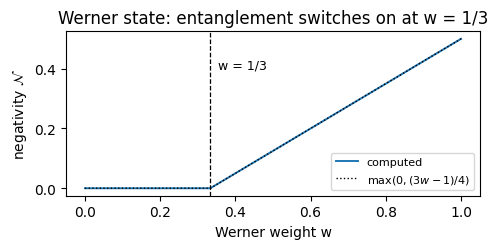

In [16]:
print("Werner state: the PPT boundary should appear at w = 1/3")
print(f"  {'w':>7s} {'min eig of PT':>14s} {'(1-3w)/4':>10s} {'negativity':>11s}")
for w in (0.20, 0.30, 1/3, 0.34, 0.50, 1.00):
    r = w * rho_bell + (1 - w) * np.eye(4) / 4
    mu = pt_min(r)
    verdict = "entangled" if neg(r) > 1e-12 else "separable (PPT)"
    print(f"  {w:7.4f} {mu:+14.6f} {(1-3*w)/4:+10.6f} {neg(r):11.6f}   {verdict}")
    assert abs(mu - (1 - 3 * w) / 4) < 1e-12

ws = np.linspace(0, 1, 201)
ns = [neg(w * rho_bell + (1 - w) * np.eye(4) / 4) for w in ws]
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot(ws, ns, lw=1.4, label="computed")
ax.plot(ws, np.maximum((3 * ws - 1) / 4, 0), "k:", lw=1.0, label=r"$\max(0,(3w-1)/4)$")
ax.axvline(1/3, ls="--", color="k", lw=0.9)
ax.text(1/3 + 0.02, max(ns) * 0.8, "w = 1/3", fontsize=9)
ax.set_xlabel("Werner weight w"); ax.set_ylabel(r"negativity $\mathcal{N}$"); ax.legend(fontsize=8)
ax.set_title("Werner state: entanglement switches on at w = 1/3")
plt.tight_layout(); plt.show()

The smallest eigenvalue of the partial transpose follows $(1-3w)/4$ to rounding, and the negativity switches on at
$w=\tfrac13$ and grows linearly to $\tfrac12$ at the pure Bell pair.

## 8. Entanglement death under noise

Section 5 made quantitative: take a Bell pair and apply the depolarising channel
$\rho\to(1-p)\rho+\tfrac p3(X\rho X+Y\rho Y+Z\rho Z)$ independently to each spin, as a noisy device would. The reduced
state entropy and the negativity behave completely differently.

The threshold can be derived. The channel shrinks the Bloch vector by $\eta = 1-\tfrac{4p}{3}$, i.e. it maps
$X\to\eta X$, $Y\to\eta Y$, $Z\to\eta Z$ and $\mathbb 1\to\mathbb 1$. Since
$\vert\Phi^+\rangle\langle\Phi^+\vert = \tfrac14(\mathbb 1 + XX - YY + ZZ)$, applying it to both spins gives
$\tfrac14(\mathbb 1 + \eta^2(XX-YY+ZZ)) = \rho_W(\eta^2)$, a Werner state with $w = (1-4p/3)^2$. It is separable for
$w\le\tfrac13$, i.e. for

$$ p \;\ge\; p^* = \tfrac34\big(1-1/\sqrt3\big) = 0.316987\ldots \text{ per spin}. $$

The cell scans $p$ on a grid that does not contain $p^*$ and then locates the boundary by bisection on the computed
negativity, without using the formula.

p per spin   purity  S(rho_A)  negativity


      0.00   1.0000    1.0000    0.500000
      0.05   0.8191    1.0000    0.403333
      0.10   0.6731    1.0000    0.313333
      0.20   0.4669    1.0000    0.153333
      0.25   0.3981    1.0000    0.083333
      0.30   0.3472    1.0000    0.020000
      0.31   0.3388    1.0000    0.008133
      0.32   0.3310    1.0000    0.000000
      0.35   0.3107    1.0000    0.000000

bisection on the computed negativity: separable from p = 0.316987 per spin
exact threshold p* = (3/4)(1 - 1/sqrt(3)) = 0.316987,  difference 1.9e-15
S(rho_A) stays at 1 bit: the depolarising channel is unital, so it maps 1/2 to itself; the input is a Bell
pair whose reduced state is already 1/2; and the channel on the other spin is trace preserving.


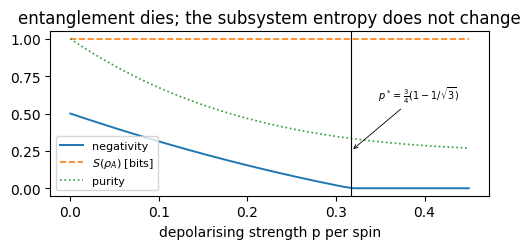

In [17]:
def noisy_bell(p):
    """Bell pair with depolarising strength p applied to each of its two spins; returns the density tensor."""
    rho = jnp.asarray(rho_bell).reshape(2, 2, 2, 2)
    for q in (0, 1):
        rho = apply_kraus_dm(rho, kraus_depolarizing(float(p)), [q])
    return rho

print(f"{'p per spin':>10s} {'purity':>8s} {'S(rho_A)':>9s} {'negativity':>11s}")
pp = np.linspace(0, 0.45, 46)
negs, purs = [], []
for p in pp:
    rho = noisy_bell(p)
    negs.append(neg(rho)); purs.append(float(purity(dm_matrix(rho))))
    if np.isclose(p, [0.0, 0.05, 0.10, 0.20, 0.25, 0.30, 0.31, 0.32, 0.35], atol=1e-9).any():
        rA = np.asarray(rdm_dm(rho, (0,)))
        print(f"{p:10.2f} {purs[-1]:8.4f} {S_bits(rA):9.4f} {negs[-1]:11.6f}")
        assert abs(S_bits(rA) - 1.0) < 1e-10

lo, hi = 0.30, 0.35                     # bracket read off the scan: entangled at 0.30, separable at 0.35
assert neg(noisy_bell(lo)) > 1e-6 and neg(noisy_bell(hi)) < 1e-14
for _ in range(40):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if neg(noisy_bell(mid)) > 1e-14 else (lo, mid)
p_star = 0.75 * (1 - 1 / np.sqrt(3))
print(f"\nbisection on the computed negativity: separable from p = {hi:.6f} per spin")
print(f"exact threshold p* = (3/4)(1 - 1/sqrt(3)) = {p_star:.6f},  difference {abs(hi-p_star):.1e}")
assert abs(hi - p_star) < 1e-6
print("S(rho_A) stays at 1 bit: the depolarising channel is unital, so it maps 1/2 to itself; the input is a Bell")
print("pair whose reduced state is already 1/2; and the channel on the other spin is trace preserving.")

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot(pp, negs, lw=1.4, label="negativity")
ax.plot(pp, [1.0] * len(pp), "--", lw=1.2, label=r"$S(\rho_A)$ [bits]")
ax.plot(pp, purs, ":", lw=1.2, label="purity")
ax.axvline(p_star, color="k", lw=0.8)
ax.annotate(r"$p^*=\frac{3}{4}(1-1/\sqrt{3})$", (p_star, 0.25), fontsize=7,
            xytext=(p_star + 0.03, 0.60), arrowprops=dict(arrowstyle="->", lw=0.6))
ax.set_xlabel("depolarising strength p per spin"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("entanglement dies; the subsystem entropy does not change")
plt.tight_layout(); plt.show()

The bisection, which knows nothing of the formula, finds the threshold $p^* = 0.316987$ to six digits. Below it the
negativity falls almost linearly from $\tfrac12$; above it the pair is separable although the global state is far
from maximally mixed (purity $1/3$ at $p^*$, against $1/4$). The reduced-state entropy reports one bit at every $p$.

## 9. A spin chain: three quantities against distance

Now the question that opened the notebook. Take the ground state of the XXZ chain in a transverse field (open chain),

$$ H = \sum_j \big(X_jX_{j+1} + Y_jY_{j+1} + \Delta\, Z_jZ_{j+1}\big) + h_x\sum_j X_j, $$

fix a reference spin $i$ next to the centre, and follow three quantities as the partner $j=i+r$ moves away:

* the **negativity** $\mathcal N(r)$ of the pair, their entanglement (and the smallest eigenvalue of the partial
  transpose, which shows the margin by which a pair is PPT);
* the **mutual information** $I(i{:}j) = S(\rho_i) + S(\rho_j) - S(\rho_{ij})$, their total correlation, classical
  and quantum together;
* the **entropy** $S(\rho_{ij})$ of the pair itself.

The four parameter points are a gapless point $\Delta=0.5$, the Heisenberg point $\Delta=1$, the Néel side
$\Delta=1.5$, and the XX chain in a transverse field $h_x=1.5$.

In [18]:
N = 14
i0 = N // 2 - 1
RS = list(range(1, N // 2 + 1))
PHASES = [("gapless, D=0.5", 0.5, 0.0), ("Heisenberg, D=1", 1.0, 0.0),
          ("Neel, D=1.5", 1.5, 0.0), ("field, hx=1.5", 0.0, 1.5)]
curves = {}
for name, D, h in PHASES:
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., D, hx=h), N)
    Si = S_bits(rdm(psi, (i0,)))
    nn, ii, ss, mm = [], [], [], []
    for r in RS:
        j = i0 + r
        rij = rdm(psi, (i0, j))
        Sij = S_bits(rij); Sj = S_bits(rdm(psi, (j,)))
        nn.append(neg(rij)); ii.append(Si + Sj - Sij); ss.append(Sij); mm.append(pt_min(rij))
    curves[name] = (nn, ii, ss)
    print(f"{name}:  S(one spin) = {Si:.4f} bit")
    print("   r       " + "".join(f"{r:8d}" for r in RS))
    print("   N(r)    " + "".join(f"{v:8.4f}" for v in nn))
    print("   min PT  " + "".join(f"{v:+8.4f}" for v in mm))
    print("   I(r)    " + "".join(f"{v:8.4f}" for v in ii))
    print("   S_ij    " + "".join(f"{v:8.4f}" for v in ss))
    assert nn[0] > 0.1 and min(mm[1:]) > 0.01       # r=1 entangled; r>=2 PPT with a finite margin

gapless, D=0.5:  S(one spin) = 1.0000 bit
   r              1       2       3       4       5       6       7
   N(r)      0.2755  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   min PT   -0.2755 +0.1199 +0.0509 +0.1640 +0.1186 +0.1929 +0.1528
   I(r)      0.8965  0.1884  0.1537  0.0607  0.0717  0.0243  0.0400
   S_ij      1.1035  1.8116  1.8463  1.9393  1.9283  1.9757  1.9600


Heisenberg, D=1:  S(one spin) = 1.0000 bit
   r              1       2       3       4       5       6       7
   N(r)      0.2924  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   min PT   -0.2924 +0.1897 +0.0531 +0.2170 +0.1258 +0.2301 +0.1612
   I(r)      0.9342  0.1618  0.1315  0.0421  0.0543  0.0146  0.0284
   S_ij      1.0658  1.8382  1.8685  1.9579  1.9457  1.9854  1.9716


Neel, D=1.5:  S(one spin) = 1.0000 bit
   r              1       2       3       4       5       6       7
   N(r)      0.2764  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   min PT   -0.2764 +0.1530 +0.0515 +0.1832 +0.1186 +0.2041 +0.1527
   I(r)      0.9042  0.1900  0.1581  0.0660  0.0783  0.0284  0.0450
   S_ij      1.0958  1.8100  1.8419  1.9340  1.9217  1.9716  1.9550


field, hx=1.5:  S(one spin) = 0.9749 bit
   r              1       2       3       4       5       6       7
   N(r)      0.2064  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   min PT   -0.2064 +0.0709 +0.1048 +0.0608 +0.1041 +0.1255 +0.0323
   I(r)      0.8251  0.2893  0.1869  0.2071  0.1042  0.1226  0.0767
   S_ij      1.1246  1.5769  1.7808  1.7117  1.7501  1.8282  1.4078


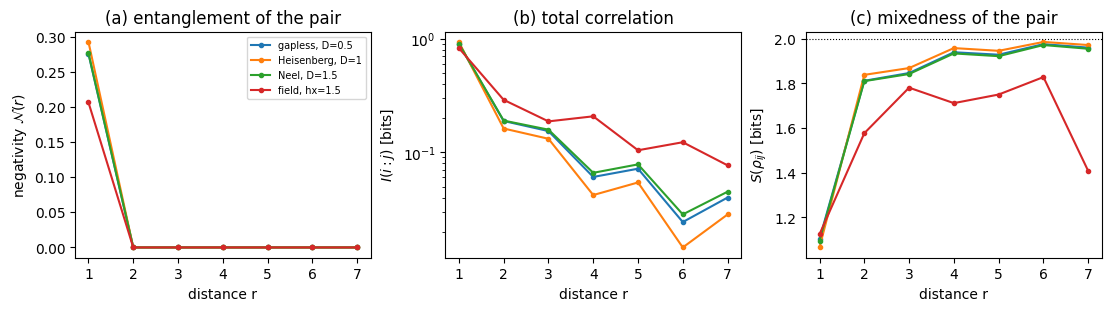

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
for name, _, _ in PHASES:
    nn, ii, ss = curves[name]
    ax[0].plot(RS, nn, "-o", ms=3, label=name)
    ax[1].semilogy(RS, np.maximum(ii, 1e-6), "-o", ms=3)
    ax[2].plot(RS, ss, "-o", ms=3)
ax[0].set_ylabel(r"negativity $\mathcal{N}(r)$"); ax[0].set_title("(a) entanglement of the pair")
ax[1].set_ylabel(r"$I(i:j)$ [bits]");   ax[1].set_title("(b) total correlation")
ax[2].set_ylabel(r"$S(\rho_{ij})$ [bits]"); ax[2].set_title("(c) mixedness of the pair")
ax[2].axhline(2.0, ls=":", color="k", lw=0.8)
for a in ax:
    a.set_xlabel("distance r")
ax[0].legend(fontsize=7)
plt.show()

**(a) Entanglement between two spins is confined to nearest neighbours here.** The negativity is $0.21$–$0.29$ at
$r=1$ and zero at every larger separation, at all four parameter points. The zero is not a small number below a
tolerance: the smallest eigenvalue of the partial transpose is *positive*, by at least $0.03$, so the partial transpose
is a state with a margin, and for two qubits that proves the pair separable.

**(b) Correlation is not entanglement.** The mutual information at $r=2$ and $r=3$ is $0.13$–$0.29$ bit and decays
slowly, with an even-odd alternation. All of that correlation is real, and none of it is entanglement. The three
zero-field points give similar curves; the field point differs, with larger mutual information at $r\ge2$.

**(c) The pair entropy measures something else.** $S(\rho_{ij})$ grows with $r$, with the same even-odd alternation,
towards $S(\rho_i)+S(\rho_j)$, which is $2$ bits at zero field, where each spin is maximally mixed. As the two spins
decorrelate, $\rho_{ij}\to\rho_i\otimes\rho_j$ and the entropy becomes the sum of the parts; equivalently
$S(\rho_{ij}) = S(\rho_i)+S(\rho_j)-I(i{:}j)$. In the field each spin is slightly polarised ($S(\rho_i) = 0.975$ bit),
and at $r=7$ the partner is the end spin of the open chain, whose polarisation is stronger, so the curve drops. A
quantity that grows as two spins are pulled apart is not measuring their mutual entanglement; for a pure global state
it measures the entanglement of the *pair* with the rest of the chain.

### Monogamy, measured

A spin of the zero-field chain is maximally mixed, so its tangle with the rest is maximal, $\tau_i = 4\det\rho_i = 1$.
The monogamy inequality of Section 3 says how much of it pairs can hold: $\sum_j C_{ij}^2 \le \tau_i$. The cell
computes every pair concurrence of a central spin.

In [20]:
Nm = 10
c = Nm // 2 - 1
print(f"open chain N={Nm}, reference spin {c}: monogamy  sum_j C_cj^2 <= tau_c = 4 det rho_c")
for D in (0.0, 1.0, 2.0):
    _, psi = lanczos_ground_state(heisenberg_terms(Nm, 1., 1., D, hx=0.0), Nm)
    tau = 4 * float(np.linalg.det(np.asarray(rdm(psi, (c,)))).real)
    Cs = [(j, concurrence(rdm(psi, (c, j))), neg(rdm(psi, (c, j)))) for j in range(Nm) if j != c]
    sumC2 = sum(C ** 2 for _, C, _ in Cs)
    print(f"  Delta={D:3.1f}: tau = {tau:.6f}   sum C^2 = {sumC2:.6f}   residual tau - sum C^2 = {tau-sumC2:.6f}")
    print(f"             non-zero pairs (j, C, N): {[(j, round(C,4), round(n,4)) for j, C, n in Cs if C > 1e-10]}")
    assert sumC2 <= tau + 1e-10
    assert all(abs(C - 2 * n) < 1e-8 for _, C, n in Cs)    # C = 2N for these pair states (see text)

open chain N=10, reference spin 4: monogamy  sum_j C_cj^2 <= tau_c = 4 det rho_c


  Delta=0.0: tau = 1.000000   sum C^2 = 0.282820   residual tau - sum C^2 = 0.717180
             non-zero pairs (j, C, N): [(3, 0.192, 0.096), (5, 0.4959, 0.248)]


  Delta=1.0: tau = 1.000000   sum C^2 = 0.416403   residual tau - sum C^2 = 0.583597
             non-zero pairs (j, C, N): [(3, 0.1436, 0.0718), (5, 0.6291, 0.3146)]


  Delta=2.0: tau = 1.000000   sum C^2 = 0.315040   residual tau - sum C^2 = 0.684960
             non-zero pairs (j, C, N): [(3, 0.1739, 0.087), (5, 0.5336, 0.2668)]


The bound holds with room to spare: the two neighbours hold $28$–$42\,\%$ of the tangle ($\sum_jC^2 = 0.28$, $0.42$
and $0.32$ at $\Delta = 0, 1, 2$), and the rest, the *residual tangle*, is in no pair at all; it is entanglement shared
among three or more spins. The bond to the right, $(4,5)$, is the strong bond of the open chain and carries most of the
pairwise part.

The cell also checks $C = 2\mathcal N$ for every pair. That is a property of these states, not a general law: at zero
field the pair state commutes with $Z_iZ_j$ and is real, so it is an X state, and for an X state with a single
negative partial-transpose eigenvalue $C = 2\mathcal N$ exactly when the relevant diagonal entries are equal, which the
symmetry of $H$ under flipping all spins ensures here. In general only $C \ge 2\mathcal N$ holds for two qubits.

Monogamy bounds the *sum* of the pairwise entanglement; it does not by itself force the more distant pairs to zero,
since the bound is not saturated. The zeros at $r\ge2$ come from the positive margin of the partial transpose measured
in Section 9(a): each distant pair is mixed enough, by its entanglement with the rest of the chain, to be separable.

## 10. The phase diagram in two measures

The comparison so far used chosen states. Now it is made across the $(\Delta, h_x)$ plane of the XXZ chain in a
transverse field. The question is whether the half-chain entropy and the nearest-neighbour negativity are two
estimates of one thing; if they were, they would take their largest values at the same place.

The map below is $N=12$ on a $9\times9$ grid (under a minute), steps $0.5$ in $\Delta$ and $0.25$ in $h_x$, so that
Section 14 can compare with it point by point. One region needs care before looking at the colours. For $\Delta<-1$ and $h_x=0$ the chain is a
ferromagnet along $z$ (rotate every second spin by $\pi$ about $z$: $XX+YY\to-(XX+YY)$, and $H$ becomes the
ferromagnetic XXZ chain with anisotropy $\vert\Delta\vert>1$). There $\vert0\ldots0\rangle$ and $\vert1\ldots1\rangle$
are exact eigenstates with the same energy $\Delta(N-1)$ (each bond contributes $\Delta$ and the $XX+YY$ terms
annihilate them), and they are the ground states. The doublet is **exactly** degenerate at every $N$, so the ground
state is any superposition $a\vert0\ldots0\rangle+b\vert1\ldots1\rangle$, and Lanczos returns whichever superposition
its random start vector selects. The half-chain entropy of that state is the binary entropy $H_2(\vert a\vert^2)$,
anything between $0$ and $1$ bit, and it is a property of the solver's start vector, not of the Hamiltonian. The
nearest-neighbour pair state is $\vert a\vert^2\vert00\rangle\langle00\vert+\vert b\vert^2\vert11\rangle\langle11\vert$
for every choice, a mixture of products, so its negativity is exactly zero. At $\Delta=-1$, $h_x=0$ the rotated chain
is the isotropic ferromagnet, whose ground level is the whole spin-$N/2$ multiplet, $(N+1)$-fold degenerate, and the
same caveat applies with more freedom.

In [21]:
print("the exactly degenerate ferromagnetic doublet, N=12, Delta=-2, hx=0:")
for k in range(3):
    E, pv = lanczos_ground_state(heisenberg_terms(12, 1., 1., -2.0), 12, key=jax.random.PRNGKey(k))
    amp = np.asarray(pv).reshape(-1)
    print(f"  start key {k}: E = {E:.10f} (Delta(N-1) = -22)   |a|^2 = {abs(amp[0])**2:.4f}  |b|^2 = {abs(amp[-1])**2:.4f}"
          f"   S_half = {float(entanglement_entropy(pv, tuple(range(6)))):.4f} bit   N(5,6) = {neg(rdm(pv,(5,6))):.1e}")

the exactly degenerate ferromagnetic doublet, N=12, Delta=-2, hx=0:


  start key 0: E = -22.0000000000 (Delta(N-1) = -22)   |a|^2 = 0.7291  |b|^2 = 0.2709   S_half = 0.8427 bit   N(5,6) = 7.1e-16


  start key 1: E = -22.0000000000 (Delta(N-1) = -22)   |a|^2 = 0.7810  |b|^2 = 0.2190   S_half = 0.7583 bit   N(5,6) = 7.8e-16


  start key 2: E = -22.0000000000 (Delta(N-1) = -22)   |a|^2 = 0.7750  |b|^2 = 0.2250   S_half = 0.7692 bit   N(5,6) = 1.2e-15


Three start vectors give three different entropies and the same zero negativity. With that in mind, the map.

In [22]:
Nmap, ng = 12, 9
Ds = np.linspace(-2.0, 2.0, ng)
hs = np.linspace(0.0, 2.0, ng)
cm = Nmap // 2 - 1
S_map = np.zeros((ng, ng)); N_map = np.zeros((ng, ng)); I_map = np.zeros((ng, ng))
t0 = time.perf_counter()
for a, hv in enumerate(hs):
    for b, Dv in enumerate(Ds):
        _, pv = lanczos_ground_state(heisenberg_terms(Nmap, 1., 1., Dv, hx=hv), Nmap)
        S_map[a, b] = float(entanglement_entropy(pv, tuple(range(Nmap // 2))))
        rij = rdm(pv, (cm, cm + 1))
        N_map[a, b] = neg(rij)
        Si = S_bits(rdm(pv, (cm,))); Sj = S_bits(rdm(pv, (cm + 1,)))
        I_map[a, b] = Si + Sj - S_bits(rij)
print(f"{ng}x{ng} grid at N={Nmap} in {time.perf_counter()-t0:.1f} s")

degen = (hs[:, None] == 0.0) & (Ds[None, :] <= -1.0)       # the exactly degenerate ferromagnetic line (and Delta = -1)
S_ok = np.where(degen, -np.inf, S_map)
iS = np.unravel_index(S_ok.argmax(), S_map.shape)
iN = np.unravel_index(N_map.argmax(), N_map.shape)
print(f"  half-chain entropy: range {S_map.min():.3f} .. {S_map.max():.3f} bits; max outside the degenerate line "
      f"{S_map[iS]:.3f} at (Delta,hx) = ({Ds[iS[1]]:+.2f}, {hs[iS[0]]:.2f})")
print(f"  nn negativity     : range {N_map.min():.3f} .. {N_map.max():.3f},       "
      f"max at (Delta,hx) = ({Ds[iN[1]]:+.2f}, {hs[iN[0]]:.2f})")
print(f"  mutual information: range {I_map.min():.3f} .. {I_map.max():.3f} bits  (never zero anywhere)")
print(f"  the two maxima are at different points: {iS != iN}")
zero = N_map < 1e-10
print(f"\n  points with negativity < 1e-10: {int(zero.sum())} of {N_map.size}, at (Delta,hx) = "
      f"{[(round(float(Ds[b]),2), round(float(hs[a]),2)) for a, b in zip(*np.nonzero(zero))]}")
print(f"  smallest negativity elsewhere: {N_map[~zero].min():.4f}")
ife = int(np.argmin(np.abs(Ds + 2.0)))
print(f"  ferromagnetic corner (Delta={Ds[ife]:+.2f}, hx=0): S = {S_map[0, ife]:.4f} bits (start-vector dependent), "
      f"I = {I_map[0, ife]:.4f} bits, negativity = {N_map[0, ife]:.1e}")

9x9 grid at N=12 in 64.1 s
  half-chain entropy: range 0.430 .. 2.323 bits; max outside the degenerate line 1.750 at (Delta,hx) = (-1.00, 0.25)
  nn negativity     : range 0.000 .. 0.320,       max at (Delta,hx) = (+0.50, 1.00)
  mutual information: range 0.286 .. 1.069 bits  (never zero anywhere)
  the two maxima are at different points: True

  points with negativity < 1e-10: 3 of 81, at (Delta,hx) = [(-2.0, 0.0), (-1.5, 0.0), (-1.0, 0.0)]
  smallest negativity elsewhere: 0.0008
  ferromagnetic corner (Delta=-2.00, hx=0): S = 0.8427 bits (start-vector dependent), I = 0.8427 bits, negativity = 7.1e-16


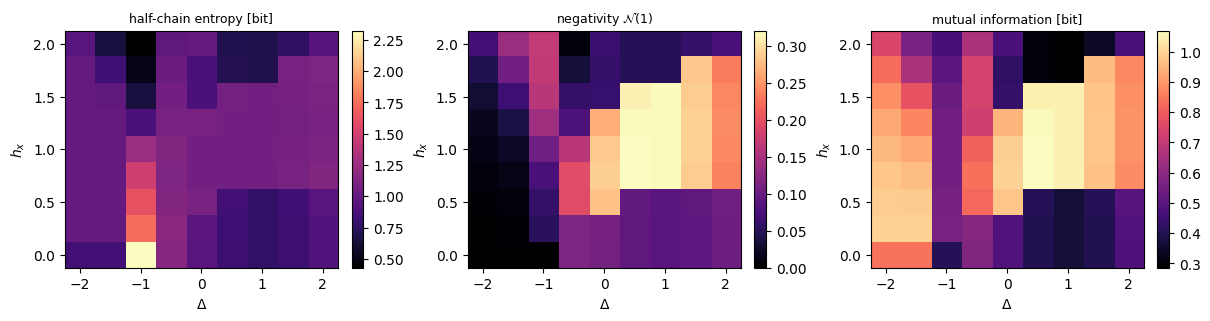

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.1), constrained_layout=True)
for a, (M, ttl) in enumerate(((S_map, "half-chain entropy [bit]"),
                              (N_map, r"negativity $\mathcal{N}(1)$"),
                              (I_map, "mutual information [bit]"))):
    im = ax[a].imshow(M, origin="lower", aspect="auto", cmap="magma",
                      extent=[Ds[0] - 0.25, Ds[-1] + 0.25, hs[0] - 0.125, hs[-1] + 0.125])
    ax[a].set_xlabel(r"$\Delta$"); ax[a].set_ylabel(r"$h_x$"); ax[a].set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax[a])
plt.show()

The two maxima are at different places. The overall entropy maximum, $2.32$ bit, sits at the degenerate point
$(\Delta,h_x)=(-1,0)$ and is a property of the Lanczos start vector. Outside the degenerate line the entropy is largest
at $(-1, 0.25)$, next to the isotropic ferromagnetic point; the negativity is largest at positive $\Delta$ *and* finite
field, $(0.5, 1)$, where the chain is neither ordered nor field-dominated. They are not two estimates of one quantity.

The negativity is zero, to rounding, only on the zero-field line $\Delta\le-1$; everywhere else on the grid the
central pair is entangled (the smallest value is $8\times10^{-4}$). For $\Delta<-1$ the zero holds for every choice of
the degenerate ground state. At $\Delta=-1$ it does not: the multiplet contains (up to the local sublattice rotation)
the Dicke state $D_N^{(N/2)}$, whose pairs are entangled (Section 3), so the zero there is again the solver's choice. On that line the central pair
still carries mutual information equal to the half-chain entropy, $H_2(\vert a\vert^2)$, which is the classical
correlation of a mixture of $\vert00\rangle$ and $\vert11\rangle$. The half-chain entropy there is genuine
entanglement of the pure state Lanczos returned (a GHZ-like superposition carries $H_2(\vert a\vert^2)$ ebits across
the cut), but the superposition is arbitrary, so this value belongs to the solver and not to the phase.

## 11. The same measures from a matrix product state

An exact state vector limits us to about twenty spins. Both quantities can be had from a matrix product state, at
very different cost.

**The entropy is free.** An MPS in canonical form *stores* the Schmidt values of every cut, so the entanglement
entropy is a sum over numbers already in the data structure; that is what `mps_entropies` returns. This presupposes
that the stored values belong to the stored tensors. The values DMRG records during its sweeps do not, in general:
later local steps change the left block of a cut whose values were already recorded. `dmrg` therefore ends with an
exact canonicalisation pass, `mps_recanonicalise`, that recomputes `lam` from the returned tensors (notebook
[18](../ch07_tensor_networks/18_mps_tebd.ipynb), Section 6.7), and with that pass the entropies of its output are those
of the state the tensors encode.

**The negativity is not free**, because it needs the two-site reduced density matrix, and that is a contraction. For a
right-canonical MPS $B^{[k]}_{a s b}$ (left bond $a$, physical $s$, right bond $b$) and sites $i<j$:

1. Everything to the **right** of site $j$ contracts to the identity, by right-canonicity
   $\sum_{s,b} B^{[k]}_{asb}\bar B^{[k]}_{a'sb} = \delta_{aa'}$. It costs nothing.
2. Everything to the **left** of site $i$ contracts to a $\chi\times\chi$ matrix $L$, the density matrix of the bond to
   the left of site $i$. We build it from the tensors themselves, by the transfer-matrix sweep of Eq. (1) below.
3. Between $i$ and $j$, each site is traced over its physical leg, a transfer matrix.

The left sweep starts from the dummy boundary bond, $L^{(0)}=e_0e_0^{\rm T}$, and adds one site at a time,

$$ L^{(k+1)}_{bd}=\sum_{a,c,s} L^{(k)}_{ac}\,B^{[k]}_{asb}\,\bar B^{[k]}_{csd}, \tag{1} $$

which is the einsum `"ac,asb,csd->bd"`. When the bond basis is the Schmidt basis, $L^{(i)}$ equals
$\mathrm{diag}(\lambda^2)$, but using the stored $\lambda$ instead would make the result only as good as those stored
values; built from $B$, it is exact for any right-canonical MPS.

So: build the left environment, open the physical legs at site $i$, walk the transfer matrix to site $j$, and close
with the right bond traced. The cost is $O(j\,d\,\chi^3)$ with $d=2$.

In [24]:
N, chi, D, h = 12, 32, 1.5, 0.5
B, lam, hist = dmrg(xxz_mpo(N, 1., 1., D, hx=h), product_mps(("01" * N)[:N], chi)[0], chi, 6)
i, j = 4, 7

# step 0: the left environment of the cut left of site i, from the tensors alone (no lam)
L = jnp.zeros((chi, chi), dtype=B.dtype).at[0, 0].set(1.0)          # e_0 e_0^T: the dummy left bond
for k in range(i):
    L = jnp.einsum("ac,asb,csd->bd", L, B[k], jnp.conj(B[k]))
print(f"left environment of site {i}: shape {L.shape},  max|L - diag(lam[{i}]^2)| = "
      f"{np.abs(np.asarray(L) - np.diag(np.asarray(lam[i]) ** 2)).max():.1e}")

# step 1: open the physical legs at site i against the left environment
T = jnp.einsum("ax,asb,xtc->stbc", L, B[i], jnp.conj(B[i]))
print(f"after site {i}: T has shape {T.shape}   (s,t = physical of site i; b,c = bond ket/bra)")

# step 2: walk through the sites in between, tracing their physical legs
for k in range(i + 1, j):
    T = jnp.einsum("stbc,bud,cue->stde", T, B[k], jnp.conj(B[k]))
    print(f"  through site {k}: shape {T.shape}   (physical leg u is summed -> traced out)")

# step 3: close at site j, keeping its physical legs open and tracing the right bond
R = jnp.einsum("stbc,bud,cvd->sutv", T, B[j], jnp.conj(B[j]))
rho_mps = R.reshape(4, 4)
print(f"\nrho has shape {rho_mps.shape}, trace {float(jnp.trace(rho_mps).real):.12f}")
print("and the engine function does exactly this:")
print("  max|by hand - mps_rdm2| =", np.abs(np.asarray(rho_mps) - np.asarray(mps_rdm2(B, lam, i, j))).max())

left environment of site 4: shape (32, 32),  max|L - diag(lam[4]^2)| = 6.7e-16
after site 4: T has shape (2, 2, 32, 32)   (s,t = physical of site i; b,c = bond ket/bra)


  through site 5: shape (2, 2, 32, 32)   (physical leg u is summed -> traced out)
  through site 6: shape (2, 2, 32, 32)   (physical leg u is summed -> traced out)

rho has shape (4, 4), trace 1.000000000000
and the engine function does exactly this:
  max|by hand - mps_rdm2| = 0.0


The left environment built from the tensors equals $\mathrm{diag}(\lambda^2)$ to rounding, so after
`mps_recanonicalise` the bond basis is the Schmidt basis. The hand-written contraction reproduces `mps_rdm2` exactly.
That only shows the two codes are the same code; the next section checks them against an independent calculation.

## 12. Agreement of the two implementations

There is a size at which the agreement must be *exact*: a matrix product state with $\chi = 2^{N/2}$ discards
nothing, so at that bond dimension DMRG and exact diagonalisation solve the same problem in different coordinates.

In [25]:
print("CHECK 1 -- at chi = 2^(N/2) the MPS is exact, so everything must agree to rounding")
print(f"{'point':>12s} {'N':>2s} {'chi':>4s} | {'|dE|':>9s} {'|dS|':>9s} {'max|d rho_ij| all pairs':>24s}")
worst1 = 0.0
for name, D_, h_ in (("gapless", 0.5, 0.0), ("Heisenberg", 1.0, 0.0), ("Neel", 2.0, 0.0),
                     ("Neel+field", 1.5, 0.5), ("field", 0.0, 1.5)):
    for Nv in (4, 6, 8):
        chiv = 2 ** (Nv // 2)
        E, psi_v = lanczos_ground_state(heisenberg_terms(Nv, 1., 1., D_, hx=h_), Nv)
        Bv, lamv, hv = dmrg(xxz_mpo(Nv, 1., 1., D_, hx=h_), product_mps(("01" * Nv)[:Nv], chiv)[0], chiv, 8)
        dS = abs(float(entanglement_entropy(psi_v, tuple(range(Nv // 2))))
                 - float(np.asarray(mps_entropies(lamv))[Nv // 2]))
        drho = max(np.abs(np.asarray(rdm(psi_v, (a, b))) - np.asarray(mps_rdm2(Bv, lamv, a, b))).max()
                   for a in range(Nv - 1) for b in range(a + 1, Nv))
        worst1 = max(worst1, abs(E - hv[-1][3]), dS, drho)
        print(f"{name:>12s} {Nv:2d} {chiv:4d} | {abs(E-hv[-1][3]):9.1e} {dS:9.1e} {drho:24.1e}")
assert worst1 < 1e-10
print(f"largest difference: {worst1:.1e}")

CHECK 1 -- at chi = 2^(N/2) the MPS is exact, so everything must agree to rounding
       point  N  chi |      |dE|      |dS|  max|d rho_ij| all pairs


     gapless  4    4 |   3.6e-15   1.6e-15                  1.1e-15


     gapless  6    8 |   8.9e-15   6.7e-16                  3.7e-14


     gapless  8   16 |   3.6e-15   5.9e-15                  4.6e-15


  Heisenberg  4    4 |   2.7e-15   9.4e-16                  1.2e-15


...

        Neel  8   16 |   1.1e-14   7.8e-15                  1.3e-14
  Neel+field  4    4 |   1.8e-15   3.8e-15                  2.9e-15


  Neel+field  6    8 |   1.8e-15   1.1e-14                  3.8e-13


  Neel+field  8   16 |   3.4e-14   2.9e-13                  3.5e-13
       field  4    4 |   0.0e+00   0.0e+00                  2.8e-15


       field  6    8 |   3.6e-15   6.7e-16                  3.2e-15


       field  8   16 |   7.1e-15   3.0e-13                  1.3e-12
largest difference: 1.3e-12


Energies, entropies and all two-site reduced states agree to $10^{-12}$ or better at every point. Away from that limit
the MPS is an approximation, and *how* it converges is the second check: does the negativity converge as fast as the
energy, and is the discarded weight that DMRG reports a usable error bar for it?

In [26]:
print("CHECK 2 -- convergence in chi at N=12, (Delta,hx)=(1.5,0.5)")
E_ex, psi_ex = lanczos_ground_state(heisenberg_terms(12, 1., 1., 1.5, hx=0.5), 12)
S_ex = float(entanglement_entropy(psi_ex, tuple(range(6))))
n_ex = neg(rdm(psi_ex, (5, 6)))
print(f"  exact: E = {E_ex:.12f}   S = {S_ex:.10f} bit   N(1) = {n_ex:.10f}")
print(f"  {'chi':>4s} {'|dE|':>10s} {'|dS|':>10s} {'|dN(1)|':>10s} {'discarded wt':>13s} {'|dN|/wt':>8s}")
conv = []
for chiv in (2, 4, 8, 16, 32, 64):
    Bv, lamv, hv = dmrg(xxz_mpo(12, 1., 1., 1.5, hx=0.5), product_mps("01" * 6, chiv)[0], chiv, 8)
    eps = max(x[4] for x in hv if x[0] == hv[-1][0])
    dE = abs(E_ex - hv[-1][3])
    dS = abs(S_ex - float(np.asarray(mps_entropies(lamv))[6]))
    dn = abs(n_ex - neg(mps_rdm2(Bv, lamv, 5, 6)))
    conv.append((chiv, dE, dS, dn, eps))
    ratio = f"{dn/eps:8.1f}" if eps > 1e-20 else "     ---"
    print(f"  {chiv:4d} {dE:10.2e} {dS:10.2e} {dn:10.2e} {eps:13.2e} {ratio}")

CHECK 2 -- convergence in chi at N=12, (Delta,hx)=(1.5,0.5)


  exact: E = -24.214627348051   S = 0.8303316868 bit   N(1) = 0.0931604105
   chi       |dE|       |dS|    |dN(1)|  discarded wt  |dN|/wt


     2   6.17e-01   4.10e-01   9.36e-02      1.26e-02      7.4


     4   4.96e-02   8.42e-02   1.52e-02      1.05e-03     14.5


     8   3.08e-04   1.40e-03   1.45e-04      7.05e-06     20.5


    16   4.69e-07   3.18e-06   2.08e-07      2.72e-08      7.7


    32   9.34e-12   1.42e-10   9.70e-12      3.98e-13     24.4


    64   3.55e-14   1.12e-13   1.18e-14      3.52e-31      ---


All three errors fall together, by ten to eleven orders of magnitude between $\chi=2$ and $\chi=32$, and at $\chi=64$
(the exact bond dimension for $N=12$) they are at rounding level. The negativity error stays within a factor of seven
of the energy error at every $\chi$ in this run. The discarded weight (the largest of the last sweep) tracks both, but it is **not** an
upper bound on the negativity error: the ratio $\vert\delta\mathcal N\vert/\varepsilon$ is between about $7$ and $25$
in the converging rows. A usable error bar is therefore the change between two bond dimensions, not $\varepsilon$
itself. In general a local observable can converge like $\sqrt{\varepsilon}$, slower than the energy; that it does not
here is a measured property of this gapped point.

In [27]:
print("CHECK 3 -- is the MPS two-site reduced state a legitimate density matrix?  (the chi = 64 state of CHECK 2)")
wtr = wher = 0.0; weig = 0.0
for a in range(11):
    for b in range(a + 1, 12):
        r = np.asarray(mps_rdm2(Bv, lamv, a, b))
        wtr = max(wtr, abs(np.trace(r).real - 1)); wher = max(wher, np.abs(r - r.conj().T).max())
        weig = min(weig, np.linalg.eigvalsh(r).min())
print(f"  over all 66 pairs: |trace-1| <= {wtr:.1e}, non-hermiticity <= {wher:.1e}, "
      f"most negative eigenvalue {weig:+.1e}")
assert wtr < 1e-10 and wher < 1e-10 and weig > -1e-10

CHECK 3 -- is the MPS two-site reduced state a legitimate density matrix?  (the chi = 64 state of CHECK 2)


  over all 66 pairs: |trace-1| <= 1.3e-15, non-hermiticity <= 2.5e-16, most negative eigenvalue +0.0e+00


Unit trace, Hermiticity and positivity hold to rounding for all 66 pairs. This check matters for the negativity in
particular: a contraction returning a slightly non-positive matrix would hand the partial transpose spurious negative
eigenvalues and report entanglement where there is none.

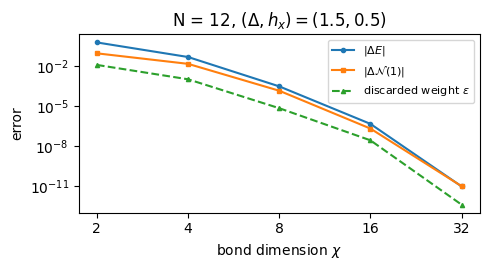

In [28]:
fig, ax = plt.subplots(figsize=(5, 2.8))
cc = [c[0] for c in conv[:-1]]                       # chi = 64 is exact: its errors are rounding
ax.loglog(cc, [c[1] for c in conv[:-1]], "-o", ms=3, label=r"$|\Delta E|$")
ax.loglog(cc, [c[3] for c in conv[:-1]], "-s", ms=3, label=r"$|\Delta \mathcal{N}(1)|$")
ax.loglog(cc, [c[4] for c in conv[:-1]], "--^", ms=3, label=r"discarded weight $\varepsilon$")
ax.set_xticks(cc); ax.set_xticklabels([str(c) for c in cc]); ax.minorticks_off()
ax.set_xlabel(r"bond dimension $\chi$"); ax.set_ylabel("error")
ax.legend(fontsize=8); ax.set_title(r"N = 12, $(\Delta, h_x) = (1.5, 0.5)$")
plt.tight_layout(); plt.show()

## 13. The cost of each route

Both methods give the same numbers, so the choice between them is cost. The cell times one ground state at increasing
$N$, with the field point of Section 12 throughout. Run it on an otherwise idle machine; the timings below come from
the build machine and vary by tens of per cent between runs. Two caveats: the DMRG column is six sweeps at $\chi=64$
throughout, so it scales linearly in a number that is a choice rather than a property of the method; and the first
Lanczos call at a new $N$ pays a compilation overhead (measured separately on the build machine: $2.0$ s for the first
call at $N=12$ against $0.4$ s for the next, $4.8$ s against $3.3$ s at $N=16$). The cell therefore warms each $N$
with a three-step Lanczos call, which costs little, before timing. What survives the caveats is the shape: one cost
grows exponentially in $N$ and the other does not.

In [29]:
print(f"{'N':>3s} | {'Lanczos [s]':>11s} {'DMRG [s]':>9s} | {'|dE|':>9s} {'|dS|':>9s} {'|dN(1)|':>9s}")
cost = []
for Nv in (12, 14, 16, 18, 20):
    cv = Nv // 2 - 1
    lanczos_ground_state(heisenberg_terms(Nv, 1., 1., 1.5, hx=0.5), Nv, m=3, restarts=1)   # warm-up at this N (cheap)
    t0 = time.perf_counter(); Ev, pv = lanczos_ground_state(heisenberg_terms(Nv, 1., 1., 1.5, hx=0.5), Nv)
    t1 = time.perf_counter()
    t2 = time.perf_counter()
    Bv, lamv, hv = dmrg(xxz_mpo(Nv, 1., 1., 1.5, hx=0.5), product_mps(("01" * Nv)[:Nv], 64)[0], 64, 6)
    t3 = time.perf_counter()
    dS = abs(float(entanglement_entropy(pv, tuple(range(Nv // 2)))) - float(np.asarray(mps_entropies(lamv))[Nv // 2]))
    dn = abs(neg(rdm(pv, (cv, cv + 1))) - neg(mps_rdm2(Bv, lamv, cv, cv + 1)))
    cost.append((Nv, t1 - t0, t3 - t2))
    print(f"{Nv:3d} | {t1-t0:11.1f} {t3-t2:9.1f} | {abs(Ev-hv[-1][3]):9.1e} {dS:9.1e} {dn:9.1e}")
    assert dS < 1e-8 and dn < 1e-8
cross = [Nv for Nv, tl, td in cost if tl > td]
print(f"\nfirst N at which Lanczos is slower than DMRG in this run: {cross[0] if cross else 'none up to 20'}")

  N | Lanczos [s]  DMRG [s] |      |dE|      |dS|   |dN(1)|


 12 |         0.9      18.5 |   3.9e-14   1.1e-13   1.5e-14


 14 |         3.6      24.1 |   2.5e-14   3.9e-13   1.1e-15


 16 |         3.2       9.2 |   8.9e-13   1.8e-12   2.3e-14


 18 |        12.6      10.7 |   3.4e-12   1.2e-11   4.1e-13


 20 |        65.1      15.2 |   2.7e-11   5.6e-11   4.2e-13

first N at which Lanczos is slower than DMRG in this run: 18


The two routes agree to $10^{-10}$ or better at every $N$, so the comparison is between equally accurate answers. The
Lanczos time grows by a factor of between about $2.5$ and $5$ per two spins, approaching the factor $4$ of the $2^N$
vector length (each of the $80$ Krylov vectors is reorthogonalised against all previous ones) once the fixed overheads
no longer dominate; the DMRG time grows roughly linearly in $N$. The crossover in
this run is printed above; past $N\approx20$ only the MPS is practical on a laptop, and the state vector itself
($2^N$ complex numbers of 16 bytes: $17$ MB at $N=20$, $69$ GB at $N=32$) stops fitting in memory a dozen spins later.

## 14. The same plane where no state vector exists

Section 10 mapped the phase diagram with an exact state vector. With `dmrg` and `mps_rdm2` validated, the same map
can be made at $N=32$, where a state vector would need $2^{32}\approx4\times10^9$ amplitudes; as a matrix product
state at $\chi=32$ it costs a few seconds per point. We run a $5\times5$ grid and compare with $N=12$ at the **same**
points.

DMRG improves its state by local updates, and a local update started from a state with a conserved quantity can only
leave that symmetry sector through rounding or through a deliberate random restart of the local solver. The Néel state
used so far has $\sum_jZ_j = 0$, and at $h_x=0$ the Hamiltonian conserves $\sum_jZ_j$; at $\Delta=1$ it conserves
$\sum_jX_j$ for any $h_x$. A product state with a generic spin direction overlaps every sector, so the runs below start
from one, and a control at one point repeats the run from the Néel state.

In [30]:
Nb, gb, chib = 32, 5, 32
Db = np.linspace(-2.0, 2.0, gb)
hb = np.linspace(0.0, 2.0, gb)
cb = Nb // 2 - 1
v_gen = np.array([np.cos(0.55), np.exp(0.7j) * np.sin(0.55)])         # a generic spin direction

def generic_mps(N, chi):
    """Product MPS with every spin along the generic direction v_gen (right-canonical: one bond index used)."""
    M0 = product_mps("0" * N, chi)[0]
    return M0.at[:, 0, :, 0].set(jnp.asarray(v_gen, dtype=M0.dtype))

S_b = np.zeros((gb, gb)); N_b = np.zeros((gb, gb)); E_b = np.zeros((gb, gb))
S_12 = np.zeros((gb, gb)); N_12 = np.zeros((gb, gb))
t0 = time.perf_counter()
for a_, hv in enumerate(hb):
    for b_, Dv in enumerate(Db):
        B_, lam_, hist_ = dmrg(xxz_mpo(Nb, 1., 1., Dv, hx=hv), generic_mps(Nb, chib), chib, 4)
        E_b[a_, b_] = hist_[-1][3]
        S_b[a_, b_] = float(np.asarray(mps_entropies(lam_))[Nb // 2])
        N_b[a_, b_] = neg(mps_rdm2(B_, lam_, cb, cb + 1))
el = time.perf_counter() - t0
for a_, hv in enumerate(hb):                     # the same points at N = 12, taken from the Section 10 map
    for b_, Dv in enumerate(Db):
        a10, b10 = int(np.argmin(np.abs(hs - hv))), int(np.argmin(np.abs(Ds - Dv)))
        assert abs(hs[a10] - hv) < 1e-12 and abs(Ds[b10] - Dv) < 1e-12
        S_12[a_, b_], N_12[a_, b_] = S_map[a10, b10], N_map[a10, b10]
print(f"{gb}x{gb} DMRG grid at N={Nb}, chi={chib}, 4 sweeps, generic start: {el:.0f} s ({el/gb**2:.1f} s per point)")

# control: the Neel start at one field point
a_c, b_c = 4, 2                                   # (Delta, hx) = (0, 2)
_, _, hN = dmrg(xxz_mpo(Nb, 1., 1., Db[b_c], hx=hb[a_c]), product_mps(("01" * Nb)[:Nb], chib)[0], chib, 4)
print(f"control at (Delta,hx) = ({Db[b_c]:+.0f}, {hb[a_c]:.1f}): E(generic start) = {E_b[a_c, b_c]:.8f}, "
      f"E(Neel start) = {hN[-1][3]:.8f}, difference {hN[-1][3]-E_b[a_c, b_c]:+.1e}")
assert abs(E_b[a_c, b_c] - hN[-1][3]) < 1e-6

print(f"\n{'(Delta,hx)':>12s} | {'S, N=12':>8s} {'S, N=32':>8s} | {'neg, N=12':>9s} {'neg, N=32':>9s}")
for a_, hv in enumerate(hb):
    for b_, Dv in enumerate(Db):
        tag = "  degenerate (h=0, Delta<=-1)" if (hv == 0 and Dv <= -1) else ("  quasi-degenerate" if Dv < -1 else "")
        print(f"  ({Dv:+.0f}, {hv:.1f}) | {S_12[a_, b_]:8.3f} {S_b[a_, b_]:8.3f} | {N_12[a_, b_]:9.4f} {N_b[a_, b_]:9.4f}{tag}")

ok = Db[None, :] > -1.5 + 0 * hb[:, None]                  # leave out the Delta = -2 column
ok &= ~((hb[:, None] == 0) & (Db[None, :] == -1))           # and the SU(2) ferromagnet at (-1, 0)
grow = (S_b > S_12 + 0.01) & ok
print(f"\nover the {int(ok.sum())} non-degenerate points: S grows from N=12 to N=32 at {int(grow.sum())}, "
      f"changes by less than 0.01 bit at {int((ok & (np.abs(S_b - S_12) <= 0.01)).sum())}, decreases at "
      f"{int((ok & (S_b < S_12 - 0.01)).sum())}")
print(f"  max S over these points: N=12 {S_12[ok].max():.3f}, N=32 {S_b[ok].max():.3f};   "
      f"max negativity: N=12 {N_12[ok].max():.3f}, N=32 {N_b[ok].max():.3f}")

5x5 DMRG grid at N=32, chi=32, 4 sweeps, generic start: 126 s (5.0 s per point)


control at (Delta,hx) = (+0, 2.0): E(generic start) = -50.54097804, E(Neel start) = -50.54097804, difference -2.0e-09

  (Delta,hx) |  S, N=12  S, N=32 | neg, N=12 neg, N=32
  (-2, 0.0) |    0.843   -0.000 |    0.0000    0.0000  degenerate (h=0, Delta<=-1)
  (-1, 0.0) |    2.323    0.001 |    0.0000    0.0005  degenerate (h=0, Delta<=-1)
  (+0, 0.0) |    0.946    1.222 |    0.1094    0.1453
  (+1, 0.0) |    0.774    1.041 |    0.0865    0.1330
  (+2, 0.0) |    0.912    1.283 |    0.1038    0.1568
  (-2, 0.5) |    1.000    0.000 |    0.0030    0.0030  quasi-degenerate
  (-1, 0.5) |    1.615    1.974 |    0.0597    0.0419
  (+0, 0.5) |    1.096    1.212 |    0.2799    0.2197
  (+1, 0.5) |    0.774    1.183 |    0.0865    0.2665
  (+2, 0.5) |    0.947    1.318 |    0.1056    0.1811
  (-2, 1.0) |    1.003    0.003 |    0.0123    0.0123  quasi-degenerate
  (-1, 1.0) |    1.245    1.499 |    0.1055    0.0917
  (+0, 1.0) |    1.072    1.239 |    0.2847    0.1288
  (+1, 1.0) |    1.062    0.97

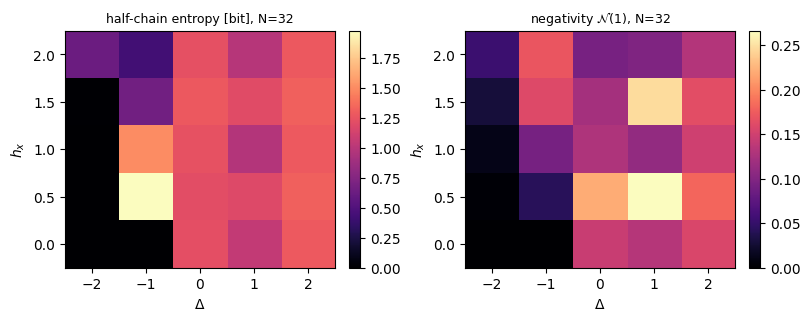

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3.1), constrained_layout=True)
for a_, (M, ttl) in enumerate(((S_b, f"half-chain entropy [bit], N={Nb}"),
                               (N_b, rf"negativity $\mathcal{{N}}(1)$, N={Nb}"))):
    im = ax[a_].imshow(M, origin="lower", aspect="auto", cmap="magma",
                       extent=[Db[0] - 0.5, Db[-1] + 0.5, hb[0] - 0.25, hb[-1] + 0.25])
    ax[a_].set_xlabel(r"$\Delta$"); ax[a_].set_ylabel(r"$h_x$"); ax[a_].set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax[a_])
plt.show()

**Starting state.** At the control point the Néel start and the generic start reach the same energy (difference
printed above), so here the result does not depend on the start. That is a property of the local solver, which
restarts from a random vector when its Krylov space closes, and it is cheap to verify; a DMRG map is only as good as
its worst point. Separately measured convergence runs ($\chi=64$, ten sweeps, same generic start) change the entropy
by at most $1.3\times10^{-4}$ bit and the negativity by at most $2\times10^{-6}$ at every point of the grid except
two. At the SU(2) ferromagnet $(-1,0)$ the ground state is a degenerate multiplet and the changes are $7\times10^{-4}$
bit and $3\times10^{-4}$. At $(\Delta,h_x)=(-2,2)$ four sweeps at $\chi=32$ are not converged: the entropy is $0.63$
bit there and $1.04$ bit at $\chi=64$ after ten sweeps, whose last sweep still lowers the energy by $10^{-6}$.

**Degenerate points.** In the $\Delta=-2$ column the two methods disagree completely about the entropy: about one bit
at $N=12$, nearly zero at $N=32$ for $h_x\le1.5$. Both are right about the state they found. At $h_x=0$ the doublet
$\vert0\ldots0\rangle,\vert1\ldots1\rangle$ is exactly degenerate (Section 10); at $h_x>0$ the field mixes the two
only at order $N$ in perturbation theory, so the splitting is exponentially small. Lanczos returns a superposition of
the two branches, a GHZ-like state with up to one bit across the cut; DMRG, which works with a limited bond dimension
and local updates, settles on a single symmetry-broken branch with entropy near zero. The negativity of the central
pair is nearly the same in both for $h_x\le1.5$ ($0.003$, $0.012$, $0.03$), because a pair state is the same mixture
of almost-product states whether the global state is the superposition or one branch. At $(\Delta,h_x)=(-1,0)$
the chain is the isotropic ferromagnet (after the rotation of Section 10), whose ground level is $(N+1)$-fold
degenerate; any value of the entropy there is a property of the solver.

**Everywhere else** the comparison is meaningful. The half-chain entropy grows from $N=12$ to $N=32$ at most of these
points, as expected for gapless chains, where it grows logarithmically with the length, and stays unchanged at the
gapped, field-polarised points such as $(-1, 2)$. The nearest-neighbour negativity does not grow systematically: it
moves up at some points and down at others, by up to about $0.2$. The largest changes are at $\Delta=1$, where
$\sum_jX_j$ is conserved and the finite-chain ground state changes magnetisation sector in discrete jumps as $h_x$
grows, at different fields for different $N$. Its maximum over these points is smaller at $N=32$ than at $N=12$. That is the difference between a quantity attached to a
cut, which has more block to grow into, and a quantity attached to one pair of neighbours, which is bounded by
monogamy and converges to its bulk value.

## 15. Key takeaways

* For a **pure** global state, entanglement across a cut is the Schmidt spectrum. The state is entangled exactly when
  the reduced state is mixed, and every pure-state measure is a function of the $p_k$; every Schur-concave function
  of them is an LOCC monotone. The entropy is singled out by asymptotic conversion: $n$ copies are interconvertible
  with $nS_A$ Bell pairs. The log-negativity of such a cut is the Rényi-$\tfrac12$ entropy and carries nothing new.
* A single number at a single cut is **not** a classification. GHZ and the Dicke state are indistinguishable by one
  spin, yet GHZ has exactly zero pairwise entanglement, from its two-spin state alone. The W state has concurrence
  $2/N$ in every pair and saturates the monogamy inequality; GHZ puts all of its tangle outside the pairs.
* For a **mixed** state the subsystem entropy is not an entanglement measure: a Bell pair and a classical coin toss
  have the same reduced state and the same one bit of entropy, and negativity $0.5$ against $0$.
* Quantifying mixed-state entanglement properly means minimising over ensembles, with a closed form only for two
  qubits; deciding separability is NP-hard in general, and $E_D$ and the negativity are not faithful. The PPT
  criterion is the computable substitute and is complete for two qubits. The negativity reproduces the Werner
  threshold $w=\tfrac13$, where the smallest partial-transpose eigenvalue $(1-3w)/4$ changes sign; under two-sided
  depolarising noise the same threshold appears as $p^* = \tfrac34(1-1/\sqrt3) = 0.316987$ per spin.
* In the XXZ ground states studied here, pairwise entanglement is nearest-neighbour at all four parameter points: the
  more distant pairs have a partial transpose that is positive with a margin of at least $0.03$, which for two qubits
  proves separability. The mutual information is long-ranged, and the pair entropy grows with separation. Monogamy
  bounds the pairwise share of a spin's tangle; the neighbours hold $28$–$42\,\%$ of it.
* Both measures come from a state vector or from an MPS. The entropy is free from the Schmidt values; the negativity
  needs a two-site reduced state, a three-step contraction costing $O(j\chi^3)$ when built from the left boundary.
  The two routes agree to $10^{-10}$ or better. The discarded weight tracks the negativity error but is not a bound on
  it, and a DMRG map needs a symmetry-breaking start and attention to degenerate points.

## 16. Exercises

1. (★) Write the two-spin reduced state of GHZ at $N=5$ and confirm it is $\tfrac12\mathrm{diag}(1,0,0,1)$. Check that
   its partial transpose has no negative eigenvalue, and explain why the two facts had to agree.
2. (★) Find the PPT boundary of the Werner state by bisection instead of by scanning, and compare with $1/3$. Then
   replace $\mathbb 1/4$ by $\vert00\rangle\langle00\vert$ and find the new threshold.
3. (★) Verify the pure-state identity $E_{\mathcal N} = 2\log_2\sum_k\lambda_k$ on a Haar-random state of eight spins
   for *every* contiguous cut $\{0,\ldots,\ell-1\}$, and plot it against $S(\ell)$.
4. (★★) For the ground state at $N=10$, $\Delta=1$, compute the concurrence of every pair containing a fixed spin and
   the residual tangle $\tau_i-\sum_jC_{ij}^2$, for each reference spin $i=0,\ldots,9$. Where along the chain is the
   pairwise share of the tangle largest, and why? Repeat at $\Delta=0$ and $\Delta=2$.
5. (★★) Generalise the contraction of Section 11 to two **blocks** of $\ell$ adjacent sites. Check that $\ell=1$
   reproduces Section 9(a), then compute the negativity between two blocks of $\ell=3$ sites separated by a gap of one
   site in the Heisenberg chain of Section 9. Is it zero? Why can a larger block be entangled when its single spins
   are not?
6. (★★) Repeat Section 8 with the dephasing channel $\rho\to(1-p)\rho+pZ\rho Z$ (`kraus_dephasing`) instead of the
   depolarising one. At what strength does the pair become separable, and why does the answer differ?
7. (★★★) Reproduce Section 13 on your own machine and locate the crossover. Then repeat the DMRG column at
   $\chi=32$ and $\chi=128$ and explain which parts of the curve move and which do not.

## 17. References

* A. Peres, *Separability criterion for density matrices*, Phys. Rev. Lett. **77**, 1413 (1996) — the PPT criterion.
* M. Horodecki, P. Horodecki, R. Horodecki, *Separability of mixed states: necessary and sufficient conditions*,
  Phys. Lett. A **223**, 1 (1996) — PPT is sufficient for $2\times2$ and $2\times3$.
* P. Horodecki, *Separability criterion and inseparable mixed states with positive partial transposition*,
  Phys. Lett. A **232**, 333 (1997) — entangled PPT states.
* M. A. Nielsen, *Conditions for a class of entanglement transformations*, Phys. Rev. Lett. **83**, 436 (1999) —
  pure-state LOCC conversion and majorisation.
* G. Vidal, *Entanglement monotones*, J. Mod. Opt. **47**, 355 (2000) — LOCC monotones of pure states.
* C. H. Bennett, H. J. Bernstein, S. Popescu, B. Schumacher, *Concentrating partial entanglement by local operations*,
  Phys. Rev. A **53**, 2046 (1996) — the entropy as the asymptotic conversion rate.
* W. Dür, G. Vidal, J. I. Cirac, *Three qubits can be entangled in two inequivalent ways*, Phys. Rev. A **62**, 062314
  (2000) — the GHZ and W classes.
* G. Vidal, R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002).
* M. B. Plenio, *Logarithmic negativity: a full entanglement monotone that is not convex*, Phys. Rev. Lett. **95**,
  090503 (2005).
* W. K. Wootters, *Entanglement of formation of an arbitrary state of two qubits*, Phys. Rev. Lett. **80**, 2245 (1998).
* V. Coffman, J. Kundu, W. K. Wootters, *Distributed entanglement*, Phys. Rev. A **61**, 052306 (2000).
* T. J. Osborne, F. Verstraete, *General monogamy inequality for bipartite qubit entanglement*, Phys. Rev. Lett.
  **96**, 220503 (2006).
* L. Gurvits, *Classical deterministic complexity of Edmonds' problem and quantum entanglement*, in Proceedings of the
  35th Annual ACM Symposium on Theory of Computing (STOC '03), 10–19 (2003) — NP-hardness of deciding separability.
* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989) — Werner states.
* L. Amico, R. Fazio, A. Osterloh, V. Vedral, *Entanglement in many-body systems*, Rev. Mod. Phys. **80**, 517 (2008).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644) · [GitHub](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/